# Explainable AI — Credit Risk EDA
### Datasets: German Credit · LendingClub · Credit Card Fraud Detection

---
**Setup Instructions:**
1. Create folder `CreditRisk_EDA` in your Google Drive root
2. Upload your files:
```
My Drive/
└── CreditRisk_EDA/
    ├── german_credit.csv
    ├── lending_club.csv
    └── creditcard.csv
```
3. Run Cell 1 → Cell 2 → then run all remaining cells


## Cell 1 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted!")

Mounted at /content/drive
Drive mounted!


## Cell 2 — Set Paths & Verify Files

In [ ]:
import os

DRIVE_FOLDER = '/content/drive/MyDrive/CreditRisk_EDA'

PATHS = {
    'german'  : os.path.join(DRIVE_FOLDER, 'german_credit.csv'),
    'lending' : os.path.join(DRIVE_FOLDER, 'lending_club.csv'),
    'fraud'   : os.path.join(DRIVE_FOLDER, 'creditcard.csv'),
}

print(f"Folder: {DRIVE_FOLDER}\n")
all_ok = True
for name, path in PATHS.items():
    exists = os.path.exists(path)
    size   = f"({os.path.getsize(path)/1e6:.1f} MB)" if exists else ""
    status = "[OK]" if exists else "[X]  MISSING"
    print(f"  {status}  {name:10s}  ->  {os.path.basename(path)}  {size}")
    if not exists:
        all_ok = False

print()
if all_ok:
    print("All files found! Run the rest of the notebook.")
else:
    print("Upload missing files to your Drive folder, then re-run this cell.")
    print("Note: german_credit.csv will auto-fetch from UCI if missing.")

Folder: /content/drive/MyDrive/CreditRisk_EDA

  [OK]  german      ->  german_credit.csv  (0.0 MB)
  [OK]  lending     ->  lending_club.csv  (1189.4 MB)
  [OK]  fraud       ->  creditcard.csv  (150.8 MB)

All files found! Run the rest of the notebook.


## Cell 3 — Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print("Libraries imported successfully")

Libraries imported successfully


---
# Dataset 1 — German Credit Dataset

## Load Dataset

In [ ]:
import os
folder = '/content/drive/MyDrive/CreditRisk_EDA'
for f in os.listdir(folder):
    size = os.path.getsize(os.path.join(folder, f)) / 1e6
    print(f"{f}  ({size:.1f} MB)")

creditcard.csv  (150.8 MB)
german_credit.csv  (0.0 MB)
lending_club.csv  (1189.4 MB)


## Basic Overview

In [ ]:
print('--- Shape ---'); print(df1.shape)
print('\n--- First 5 Rows ---'); display(df1.head())
print('\n--- Data Types ---'); display(df1.dtypes.to_frame('dtype'))
print('\n--- Statistical Summary ---'); display(df1.describe())

--- Shape ---
(1000, 21)

--- First 5 Rows ---


,checking_account,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,present_residence,property,age,other_installments,housing,existing_credits,job,liable_people,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201,1



--- Data Types ---


,dtype
checking_account,object
duration_months,int64
credit_history,object
purpose,object
credit_amount,int64
savings_account,object
employment_since,object
installment_rate,int64
personal_status_sex,object
other_debtors,object



--- Statistical Summary ---


,duration_months,credit_amount,installment_rate,present_residence,age,existing_credits,liable_people,credit_risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,0.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,0.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,0.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,0.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,1.000000


## Missing Values

In [ ]:
missing = df1.isnull().sum()
mdf1 = pd.DataFrame({'Missing Count': missing, 'Missing %': (missing/len(df1)*100).round(2)})
mdf1 = mdf1[mdf1['Missing Count'] > 0]
if mdf1.empty:
    print("No missing values found.")
else:
    display(mdf1)

No missing values found.


## Target Variable Distribution

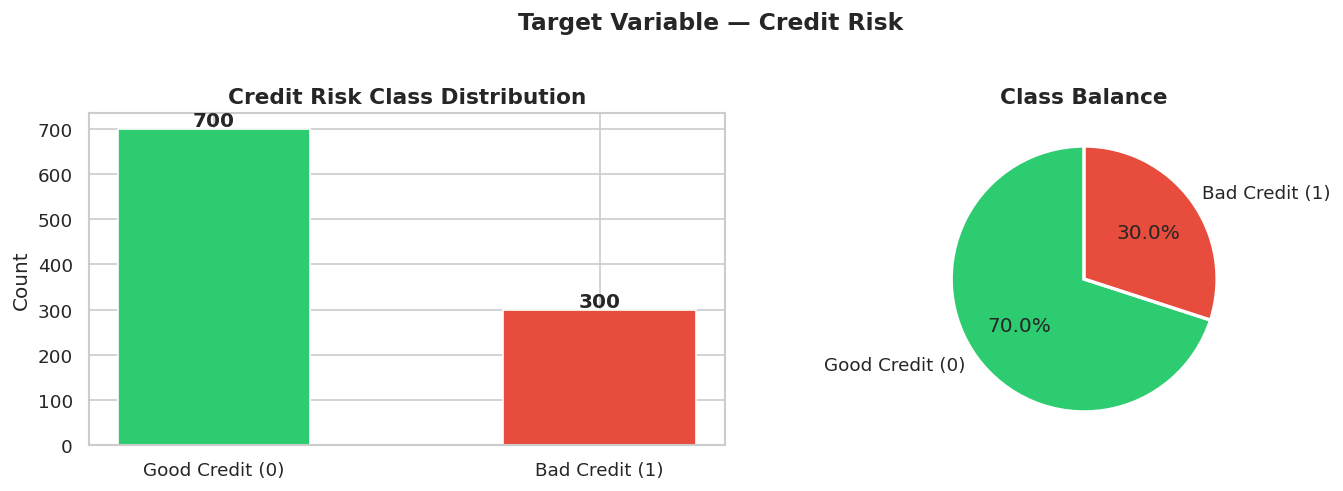

credit_risk
0    700
1    300

Imbalance ratio: 2.33:1


In [ ]:
tc = df1['credit_risk'].value_counts().sort_index()
tlabels = ['Good Credit (0)', 'Bad Credit (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(tlabels, tc.values, color=['#2ecc71','#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_title('Credit Risk Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(tc.values):
    axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')
axes[1].pie(tc.values, labels=tlabels, autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Class Balance', fontsize=13, fontweight='bold')
plt.suptitle('Target Variable — Credit Risk', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
print(tc.to_string())
print(f'\nImbalance ratio: {tc[0]/tc[1]:.2f}:1')

## Numeric Features Distribution

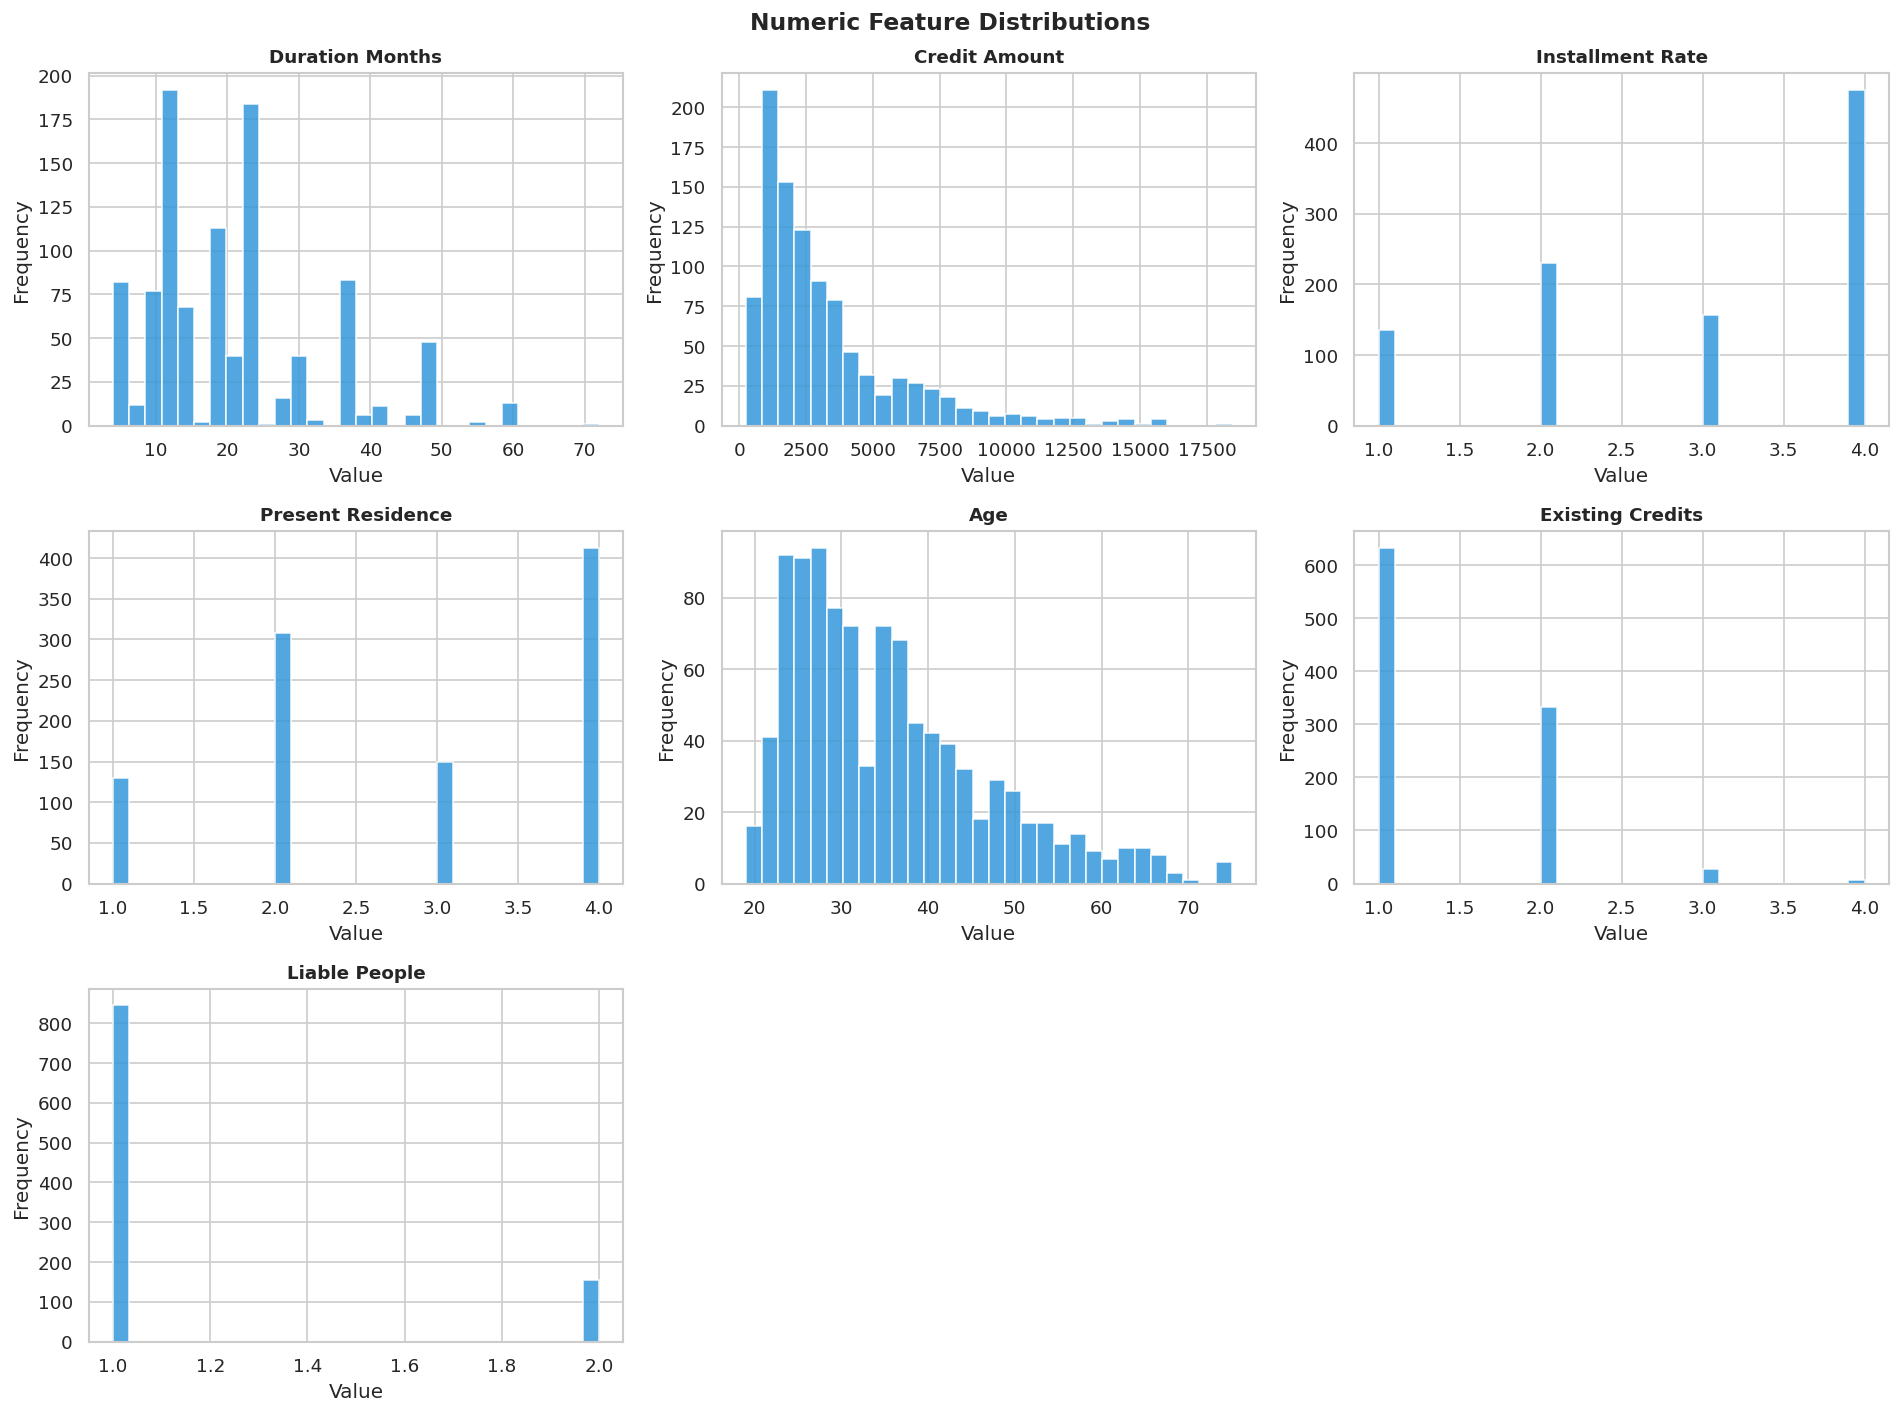

In [ ]:
num1 = [c for c in df1.select_dtypes(include=np.number).columns if c != 'credit_risk']
ncols = 3; nrows = (len(num1)+ncols-1)//ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows)); axes = axes.flatten()
for i, col in enumerate(num1):
    axes[i].hist(df1[col], bins=30, color='#3498db', edgecolor='white', alpha=0.85)
    axes[i].set_title(col.replace('_',' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value'); axes[i].set_ylabel('Frequency')
for j in range(len(num1), len(axes)): axes[j].set_visible(False)
plt.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Key Features vs Credit Risk

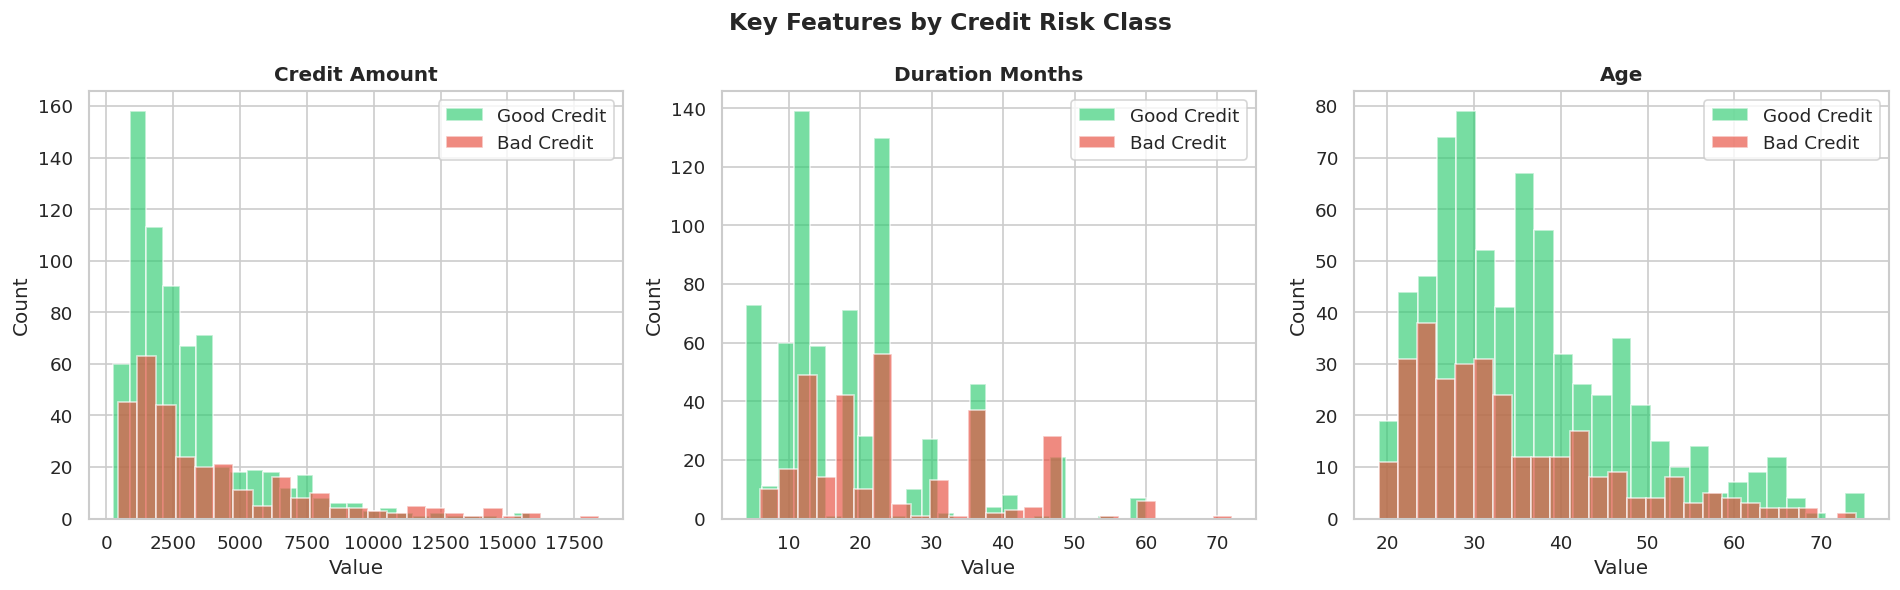

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
c_ = {0:'#2ecc71', 1:'#e74c3c'}; l_ = {0:'Good Credit', 1:'Bad Credit'}
for i, col in enumerate(['credit_amount','duration_months','age']):
    for r in [0, 1]:
        axes[i].hist(df1[df1['credit_risk']==r][col], bins=25, alpha=0.65,
                     color=c_[r], label=l_[r], edgecolor='white')
    axes[i].set_title(col.replace('_',' ').title(), fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value'); axes[i].set_ylabel('Count'); axes[i].legend()
plt.suptitle('Key Features by Credit Risk Class', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Correlation Heatmap

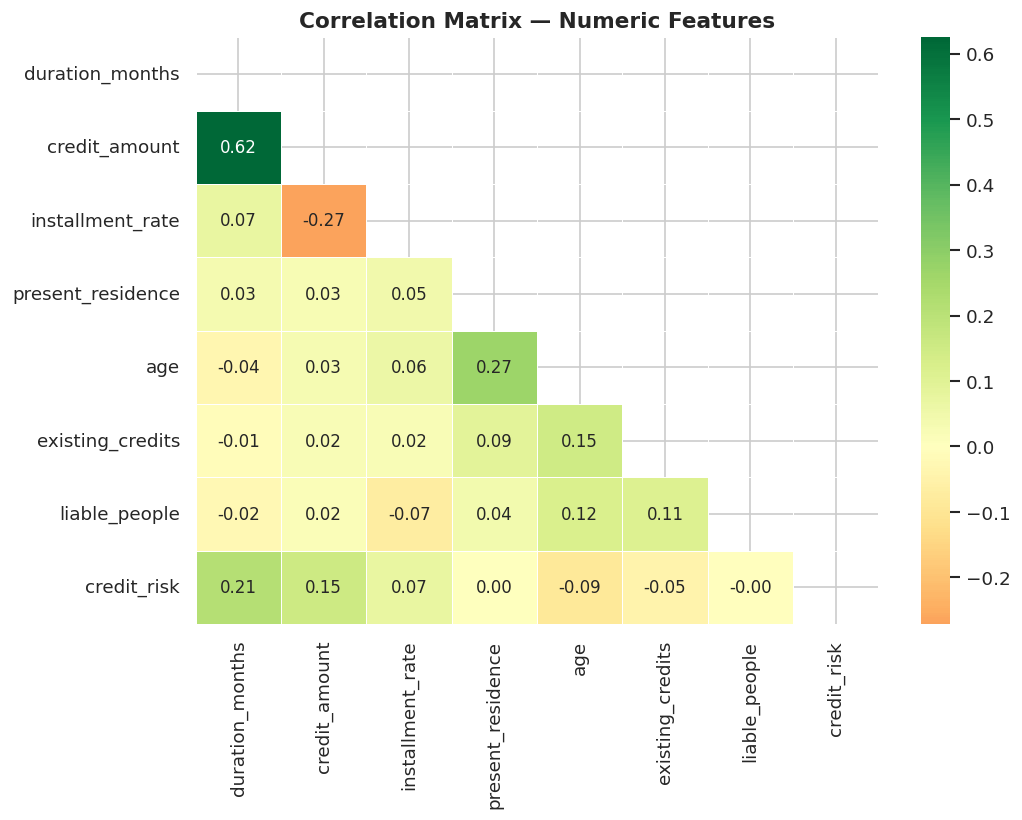

In [ ]:
corr1 = df1[num1+['credit_risk']].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr1, mask=np.triu(np.ones_like(corr1, dtype=bool)),
            annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size':10})
ax.set_title('Correlation Matrix — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## Categorical Feature Analysis

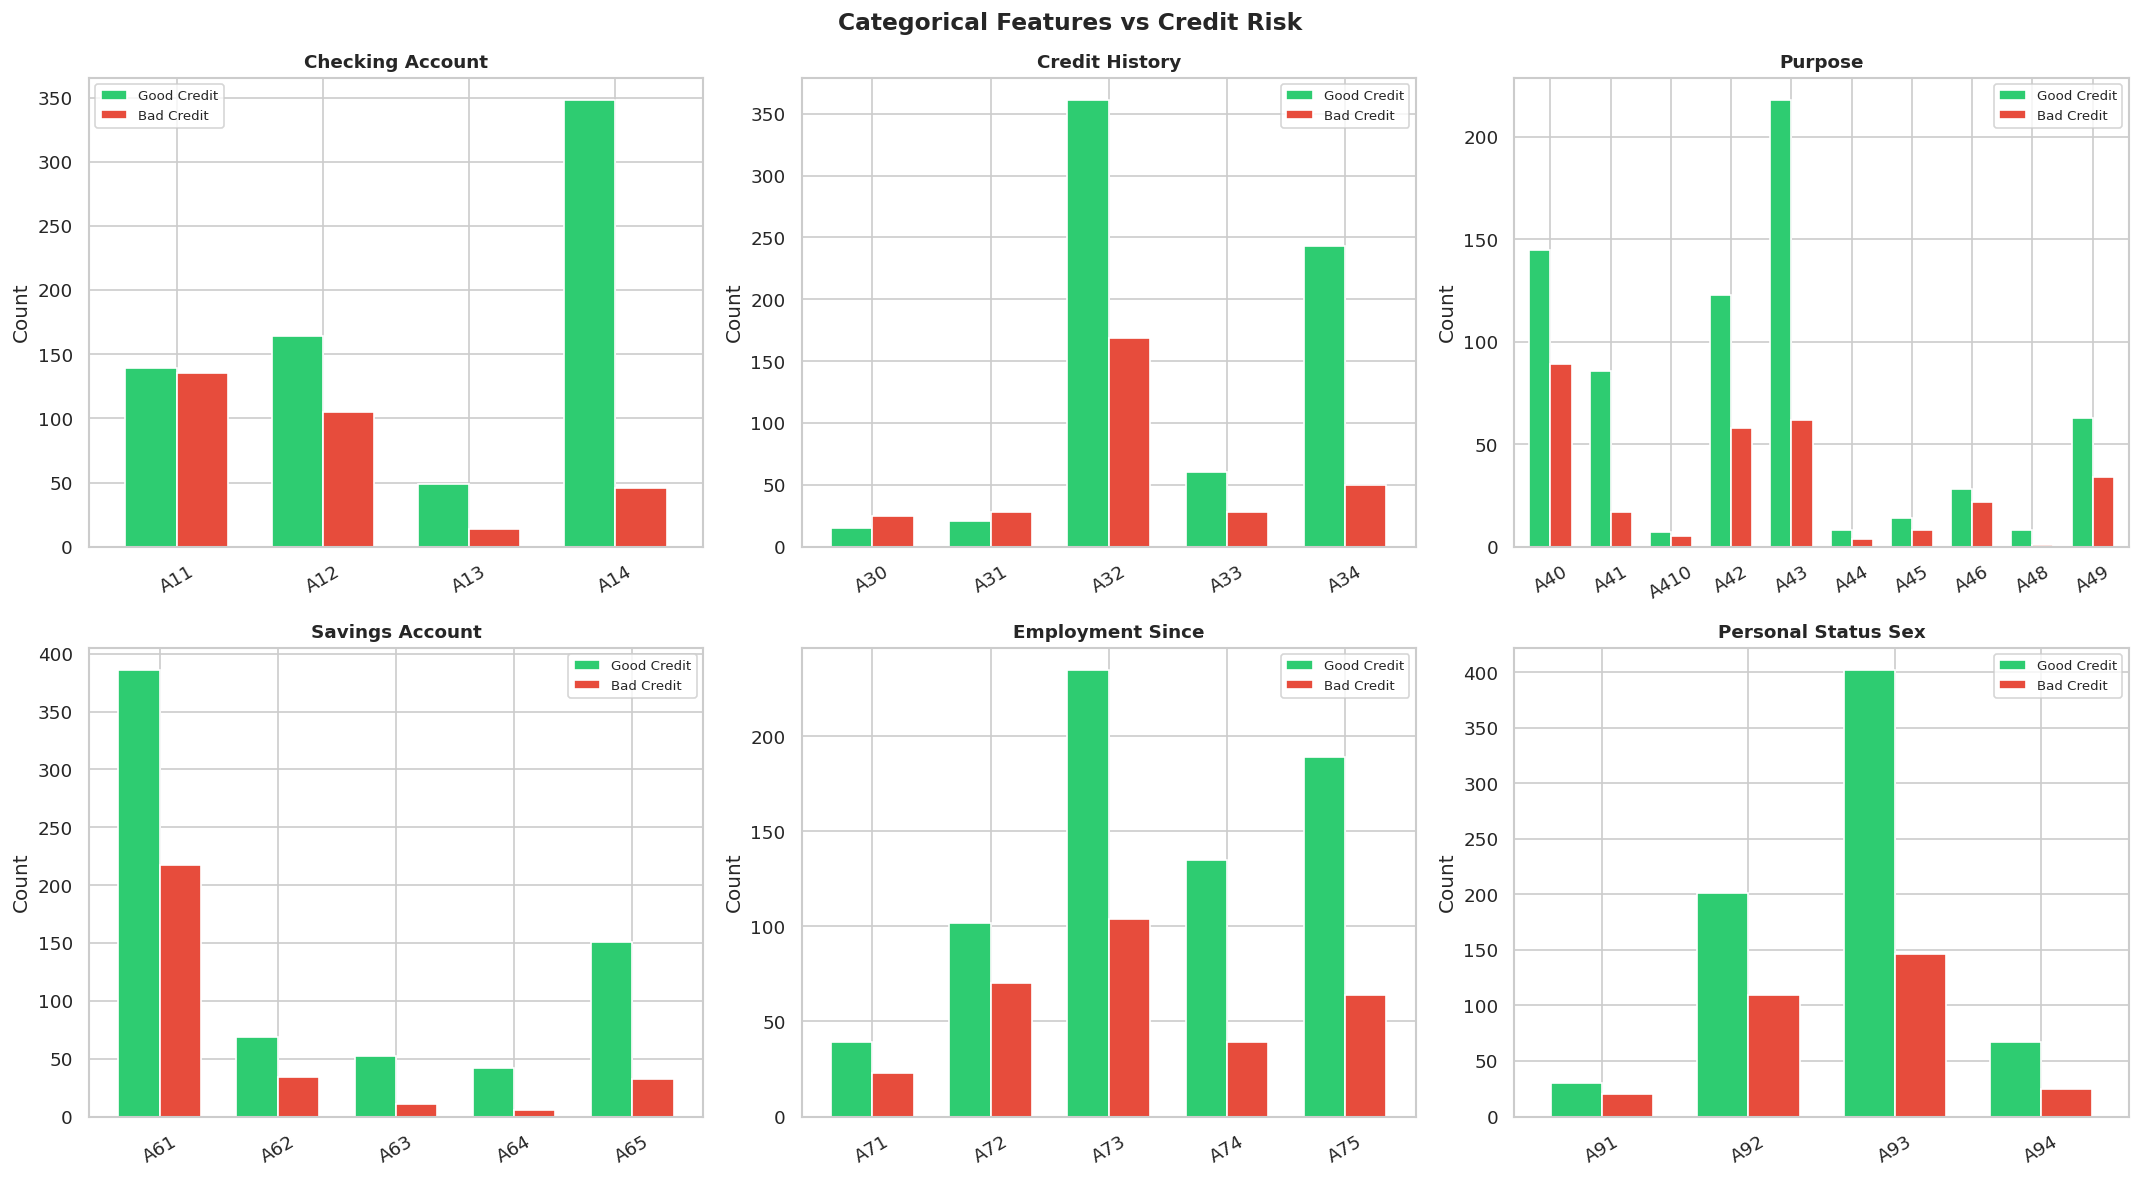

In [ ]:
cat1 = df1.select_dtypes(include='object').columns.tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 10)); axes = axes.flatten()
for i, col in enumerate(cat1[:6]):
    counts = df1.groupby([col,'credit_risk']).size().unstack(fill_value=0)
    counts.columns = ['Good Credit','Bad Credit']
    counts.plot(kind='bar', ax=axes[i], color=['#2ecc71','#e74c3c'], edgecolor='white', width=0.7)
    axes[i].set_title(col.replace('_',' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel(''); axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30); axes[i].legend(fontsize=8)
for j in range(len(cat1[:6]), len(axes)): axes[j].set_visible(False)
plt.suptitle('Categorical Features vs Credit Risk', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Outlier Detection

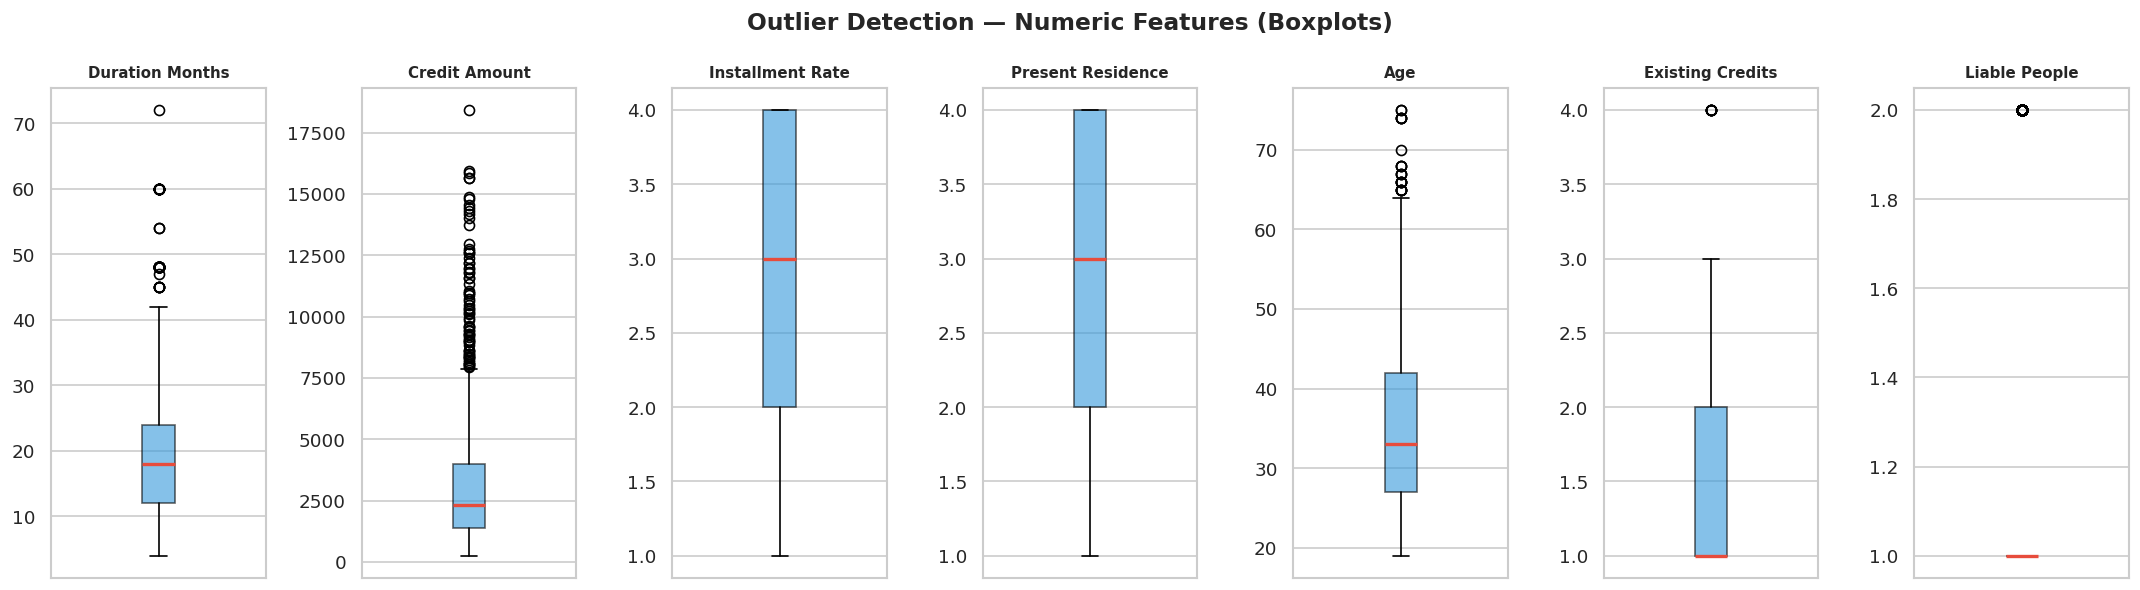

In [ ]:
fig, axes = plt.subplots(1, len(num1), figsize=(18, 5))
for i, col in enumerate(num1):
    axes[i].boxplot(df1[col], patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.6),
                    medianprops=dict(color='#e74c3c', linewidth=2))
    axes[i].set_title(col.replace('_',' ').title(), fontsize=9, fontweight='bold')
    axes[i].set_xticks([])
plt.suptitle('Outlier Detection — Numeric Features (Boxplots)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Credit Amount vs Duration Scatter

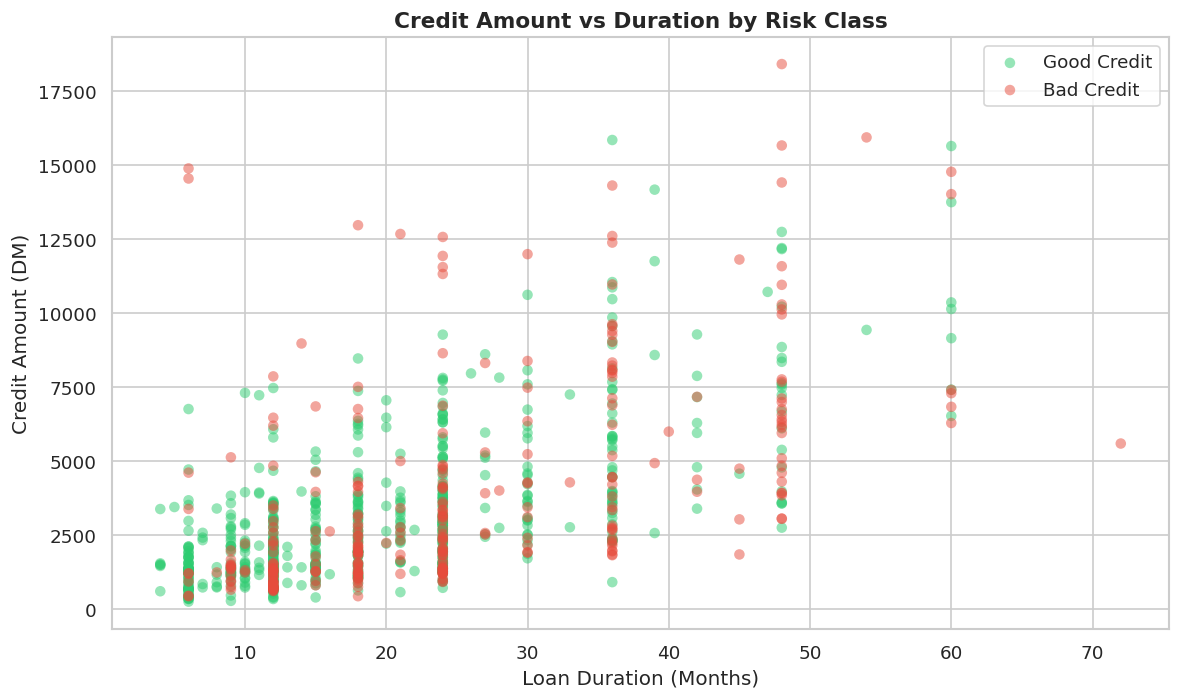

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
for r, color, label in [(0,'#2ecc71','Good Credit'),(1,'#e74c3c','Bad Credit')]:
    s = df1[df1['credit_risk']==r]
    ax.scatter(s['duration_months'], s['credit_amount'], alpha=0.5,
               c=color, label=label, edgecolors='none', s=40)
ax.set_xlabel('Loan Duration (Months)', fontsize=12)
ax.set_ylabel('Credit Amount (DM)', fontsize=12)
ax.set_title('Credit Amount vs Duration by Risk Class', fontsize=13, fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

## Summary Insights

In [ ]:
g1 = df1[df1['credit_risk']==0]; b1 = df1[df1['credit_risk']==1]
print('='*55)
print('     EDA SUMMARY — GERMAN CREDIT DATASET')
print('='*55)
print(f'  Total samples       : {len(df1)}')
print(f'  Features            : {df1.shape[1]-1}')
print(f'  Good Credit (0)     : {len(g1)} ({len(g1)/len(df1)*100:.1f}%)')
print(f'  Bad Credit  (1)     : {len(b1)}  ({len(b1)/len(df1)*100:.1f}%)')
print(f'  Missing Values      : {df1.isnull().sum().sum()}')
print('-'*55)
print(f'  Avg Credit Amount   : DM {df1["credit_amount"].mean():,.0f}')
print(f'    Good Credit       : DM {g1["credit_amount"].mean():,.0f}')
print(f'    Bad Credit        : DM {b1["credit_amount"].mean():,.0f}')
print(f'  Avg Loan Duration   : {df1["duration_months"].mean():.1f} months')
print(f'  Avg Age             : {df1["age"].mean():.1f} years')
print('='*55)

     EDA SUMMARY — GERMAN CREDIT DATASET
  Total samples       : 1000
  Features            : 20
  Good Credit (0)     : 700 (70.0%)
  Bad Credit  (1)     : 300  (30.0%)
  Missing Values      : 0
-------------------------------------------------------
  Avg Credit Amount   : DM 3,271
    Good Credit       : DM 2,985
    Bad Credit        : DM 3,938
  Avg Loan Duration   : 20.9 months
  Avg Age             : 35.5 years


---
# Dataset 2 — LendingClub Dataset

## Load Dataset

In [ ]:
LC_KEEP = ['loan_amnt','term','int_rate','grade','sub_grade','emp_length',
           'home_ownership','annual_inc','verification_status','purpose',
           'dti','delinq_2yrs','fico_range_low','open_acc','revol_util',
           'total_acc','loan_status']

load_lc_success = False

if os.path.exists(PATHS['lending']):
    try:
        df2_raw = pd.read_csv(PATHS['lending'], low_memory=False)
        existing = [c for c in LC_KEEP if c in df2_raw.columns]
        if not existing:
            raise ValueError("None of the expected LendingClub columns found.")

        df2 = df2_raw[existing].copy()

        if 'loan_status' in df2.columns:
            df2 = df2[df2['loan_status'].isin(['Fully Paid','Charged Off'])].copy()
            df2['target'] = (df2['loan_status'] == 'Charged Off').astype(int)
            df2.drop(columns=['loan_status'], inplace=True)
        elif 'target' not in df2.columns:
            raise ValueError("'loan_status' or 'target' column not found.")

        # Clean percentage columns
        for col in ['int_rate','revol_util']:
            if col in df2.columns and df2[col].dtype == object:
                df2[col] = df2[col].str.replace('%','').astype(float)
        if 'term' in df2.columns and df2['term'].dtype == object:
            df2['term'] = df2['term'].str.strip().str.replace(' months','').astype(int)

        print(f"Loaded from Drive: {df2.shape[0]} rows x {df2.shape[1]} columns")
        load_lc_success = True

    except (pd.errors.EmptyDataError, ValueError, KeyError) as e:
        print(f"Error loading LendingClub: {e}")

if not load_lc_success:
    raise FileNotFoundError(
        "lending_club.csv not found or could not be loaded.\n"
        "Upload to: MyDrive/CreditRisk_EDA/lending_club.csv\n"
        "Download from: https://www.kaggle.com/datasets/wordsforthewise/lending-club"
    )

Loaded from Drive: 1303607 rows x 16 columns


## Basic Overview

In [ ]:
print('--- Shape ---'); print(df2.shape)
print('\n--- First 5 Rows ---'); display(df2.head())
print('\n--- Data Types ---'); display(df2.dtypes.to_frame('dtype'))
print('\n--- Statistical Summary ---'); display(df2.describe())

--- Shape ---
(1303607, 16)

--- First 5 Rows ---


,loan_amnt,term,int_rate,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,open_acc,revol_util,total_acc,target
100,30000,36,22.35,D,D5,5 years,MORTGAGE,100000.0,Source Verified,debt_consolidation,30.46,0.0,11.0,37.0,19.0,0
152,40000,60,16.14,C,C4,< 1 year,MORTGAGE,45000.0,Verified,credit_card,50.53,0.0,18.0,64.5,37.0,0
170,20000,36,7.56,A,A3,10+ years,MORTGAGE,100000.0,Not Verified,credit_card,18.92,0.0,9.0,29.9,19.0,0
186,4500,36,11.31,B,B3,10+ years,RENT,38500.0,Not Verified,credit_card,4.64,0.0,12.0,15.3,25.0,0
215,8425,36,27.27,E,E5,3 years,MORTGAGE,450000.0,Verified,credit_card,12.37,0.0,21.0,65.7,37.0,0



--- Data Types ---


,dtype
loan_amnt,int64
term,int64
int_rate,float64
grade,object
sub_grade,object
emp_length,object
home_ownership,object
annual_inc,float64
verification_status,object
purpose,object



--- Statistical Summary ---


,loan_amnt,term,int_rate,annual_inc,dti,delinq_2yrs,open_acc,revol_util,total_acc,target
count,1.303607e+06,1.303607e+06,1.303607e+06,1.303607e+06,1.303295e+06,1.303607e+06,1.303607e+06,1.302797e+06,1.303607e+06,1.303607e+06
mean,1.441681e+04,4.179659e+01,1.325722e+01,7.615899e+04,1.825875e+01,3.176126e-01,1.159234e+01,5.191014e+01,2.501894e+01,2.007162e-01
std,8.699542e+03,1.027218e+01,4.760544e+00,7.004890e+04,1.093849e+01,8.772588e-01,5.465282e+00,2.450155e+01,1.199584e+01,4.005363e-01
min,5.000000e+02,3.600000e+01,5.310000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00
25%,8.000000e+03,3.600000e+01,9.750000e+00,4.584000e+04,1.179000e+01,0.000000e+00,8.000000e+00,3.360000e+01,1.600000e+01,0.000000e+00
50%,1.200000e+04,3.600000e+01,1.274000e+01,6.500000e+04,1.761000e+01,0.000000e+00,1.100000e+01,5.230000e+01,2.300000e+01,0.000000e+00
75%,2.000000e+04,3.600000e+01,1.599000e+01,9.000000e+04,2.404000e+01,0.000000e+00,1.400000e+01,7.080000e+01,3.200000e+01,0.000000e+00
max,4.000000e+04,6.000000e+01,3.099000e+01,1.099920e+07,9.990000e+02,3.900000e+01,9.000000e+01,8.923000e+02,1.760000e+02,1.000000e+00


## Missing Values

In [ ]:
missing = df2.isnull().sum()
mdf2 = pd.DataFrame({'Missing Count': missing, 'Missing %': (missing/len(df2)*100).round(2)})
mdf2 = mdf2[mdf2['Missing Count'] > 0].sort_values('Missing %', ascending=False)
if mdf2.empty:
    print("No missing values found.")
else:
    display(mdf2)

,Missing Count,Missing %
emp_length,75454,5.79
revol_util,810,0.06
dti,312,0.02


## Target Variable Distribution

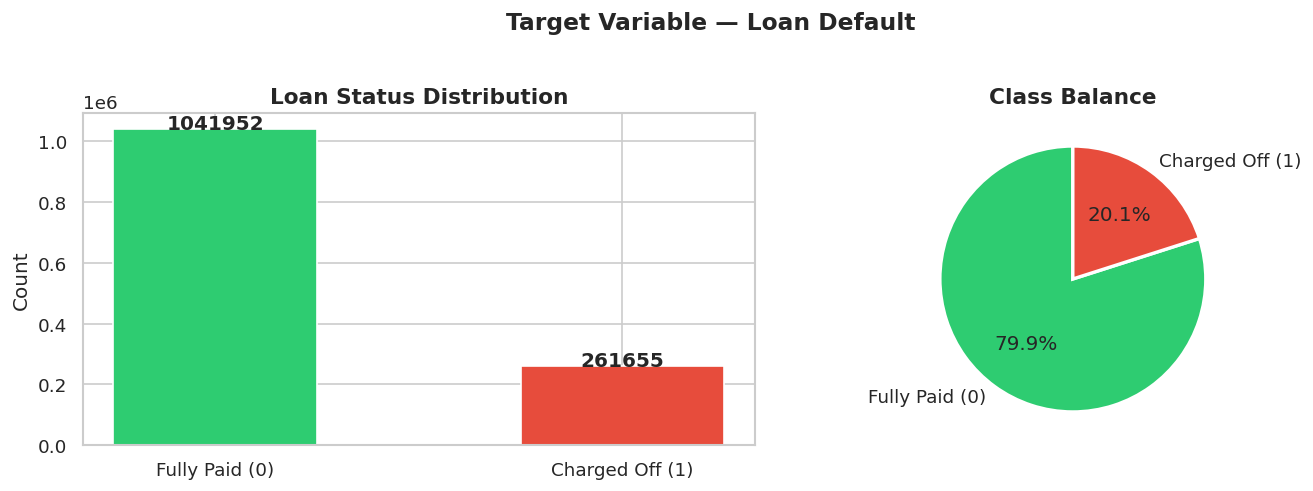

target
0    1041952
1     261655

Imbalance ratio: 3.98:1


In [ ]:
tc2 = df2['target'].value_counts().sort_index()
tl2 = ['Fully Paid (0)', 'Charged Off (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(tl2, tc2.values, color=['#2ecc71','#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_title('Loan Status Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(tc2.values):
    axes[0].text(i, v+30, str(v), ha='center', fontweight='bold')
axes[1].pie(tc2.values, labels=tl2, autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Class Balance', fontsize=13, fontweight='bold')
plt.suptitle('Target Variable — Loan Default', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
print(tc2.to_string())
print(f'\nImbalance ratio: {tc2[0]/tc2[1]:.2f}:1')

## Numeric Features Distribution

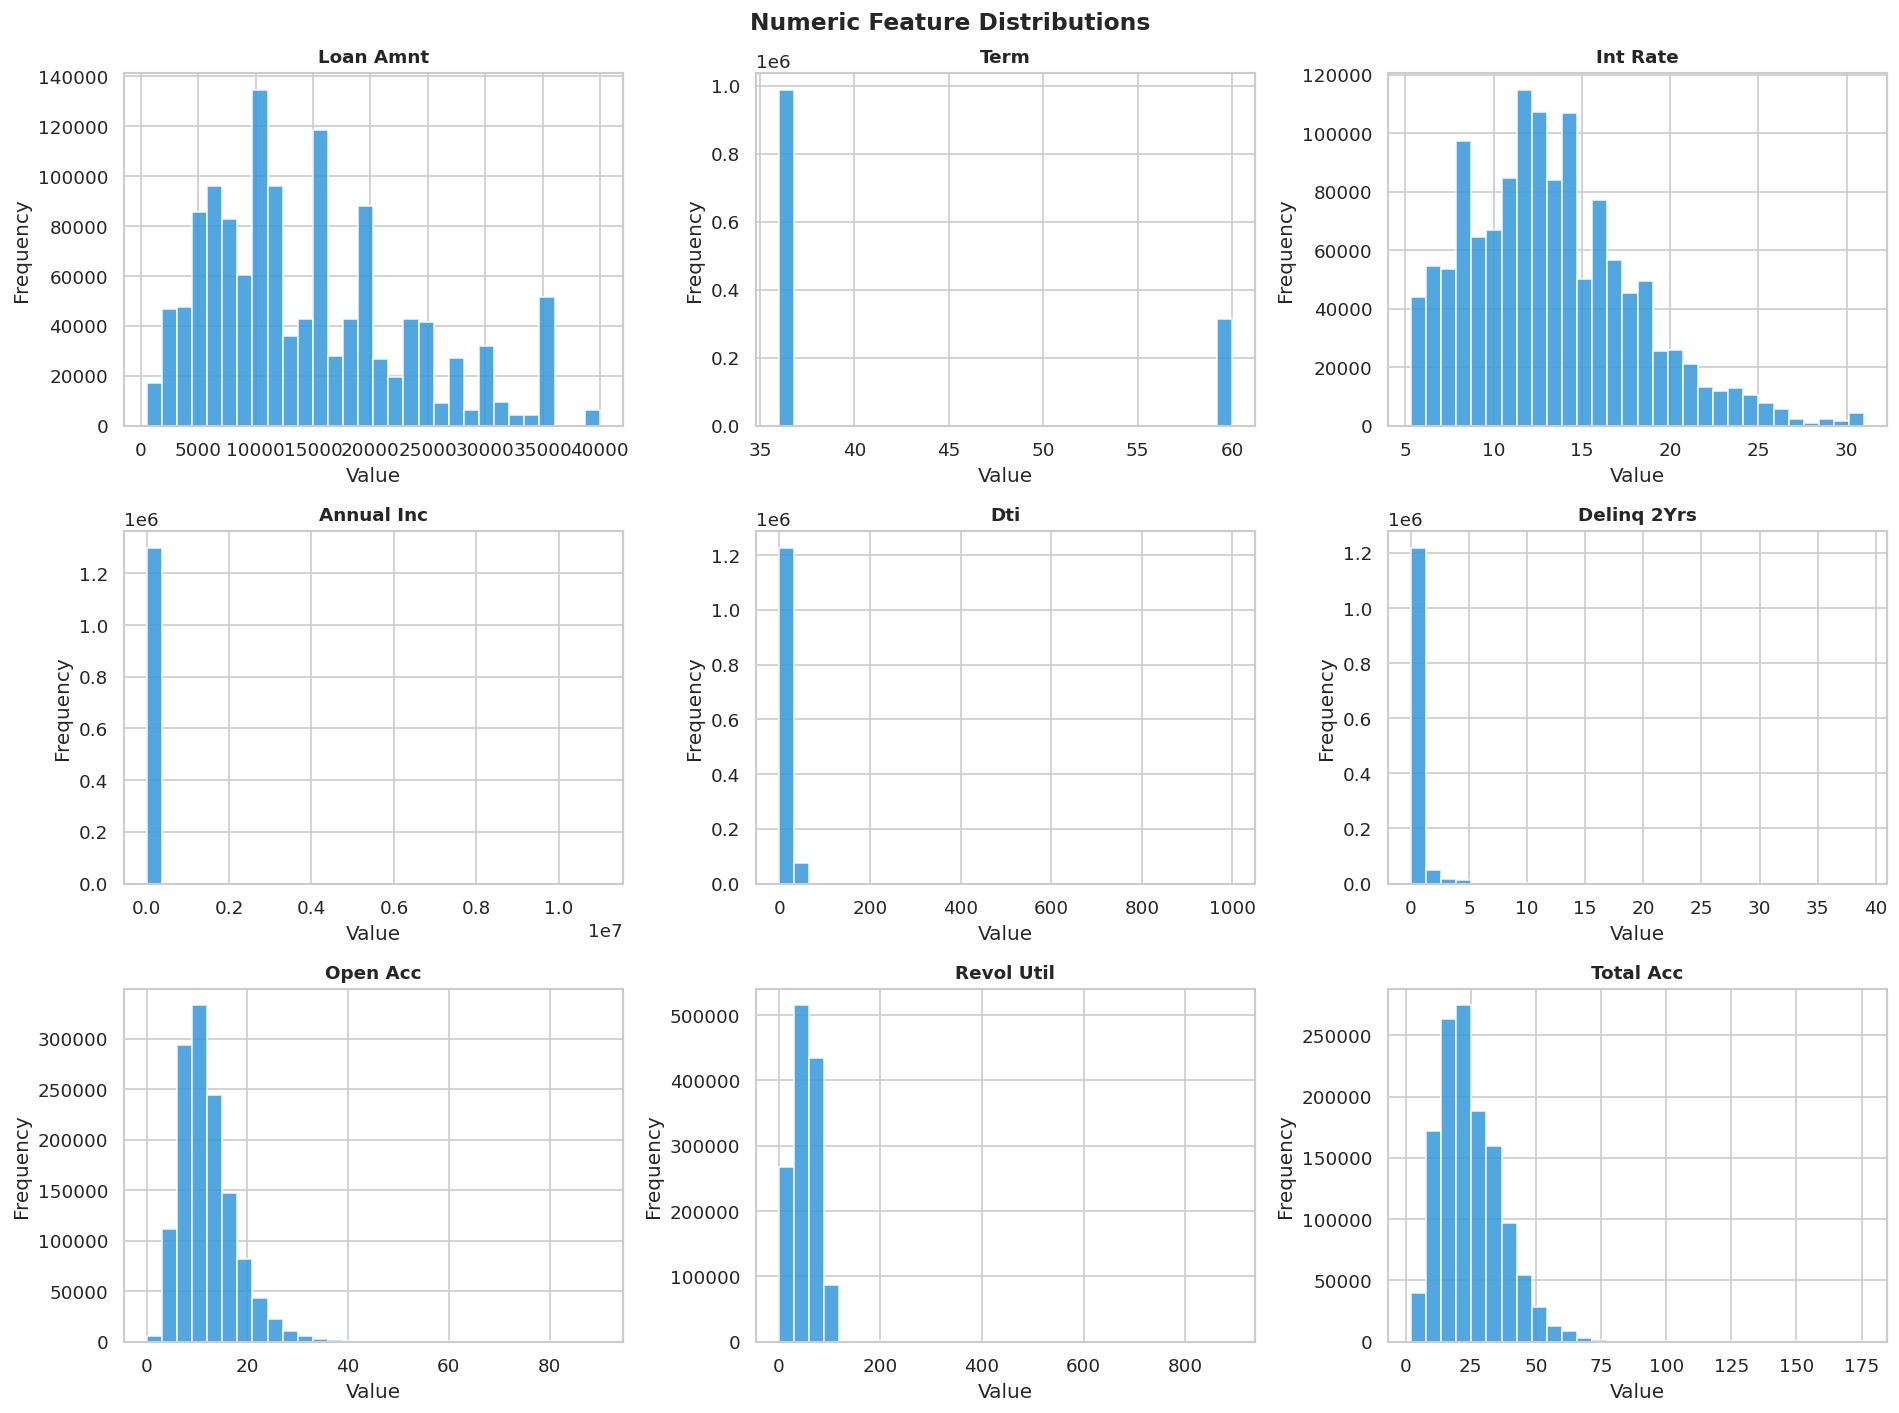

In [ ]:
num2 = [c for c in df2.select_dtypes(include=np.number).columns if c != 'target']
ncols = 3; nrows = (len(num2)+ncols-1)//ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows)); axes = axes.flatten()
for i, col in enumerate(num2):
    axes[i].hist(df2[col].dropna(), bins=30, color='#3498db', edgecolor='white', alpha=0.85)
    axes[i].set_title(col.replace('_',' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value'); axes[i].set_ylabel('Frequency')
for j in range(len(num2), len(axes)): axes[j].set_visible(False)
plt.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Key Features vs Loan Default

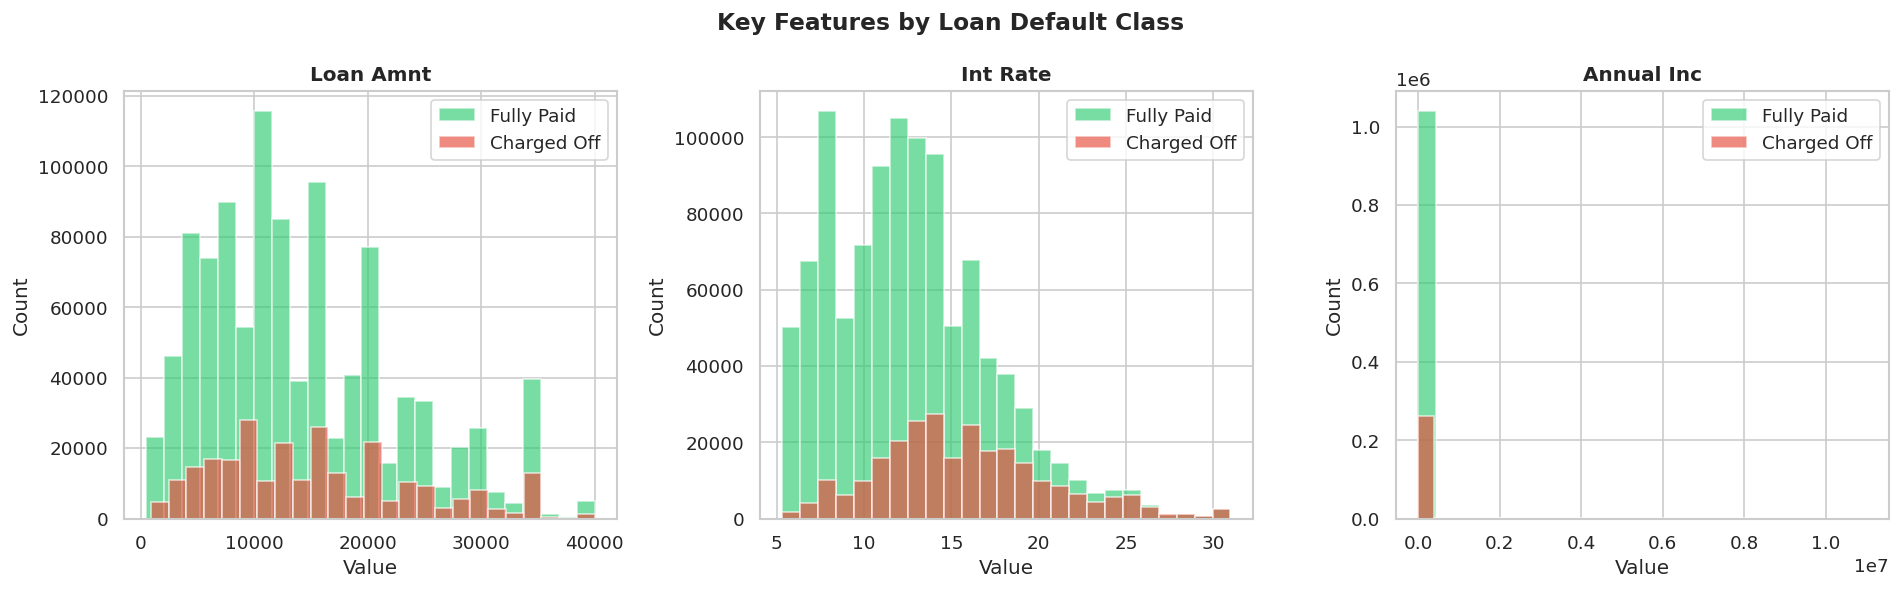

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
c_ = {0:'#2ecc71', 1:'#e74c3c'}; l_ = {0:'Fully Paid', 1:'Charged Off'}
key2 = [c for c in ['loan_amnt','int_rate','annual_inc'] if c in df2.columns]
for i, col in enumerate(key2):
    for t in [0, 1]:
        axes[i].hist(df2[df2['target']==t][col].dropna(), bins=25, alpha=0.65,
                     color=c_[t], label=l_[t], edgecolor='white')
    axes[i].set_title(col.replace('_',' ').title(), fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value'); axes[i].set_ylabel('Count'); axes[i].legend()
plt.suptitle('Key Features by Loan Default Class', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Correlation Heatmap

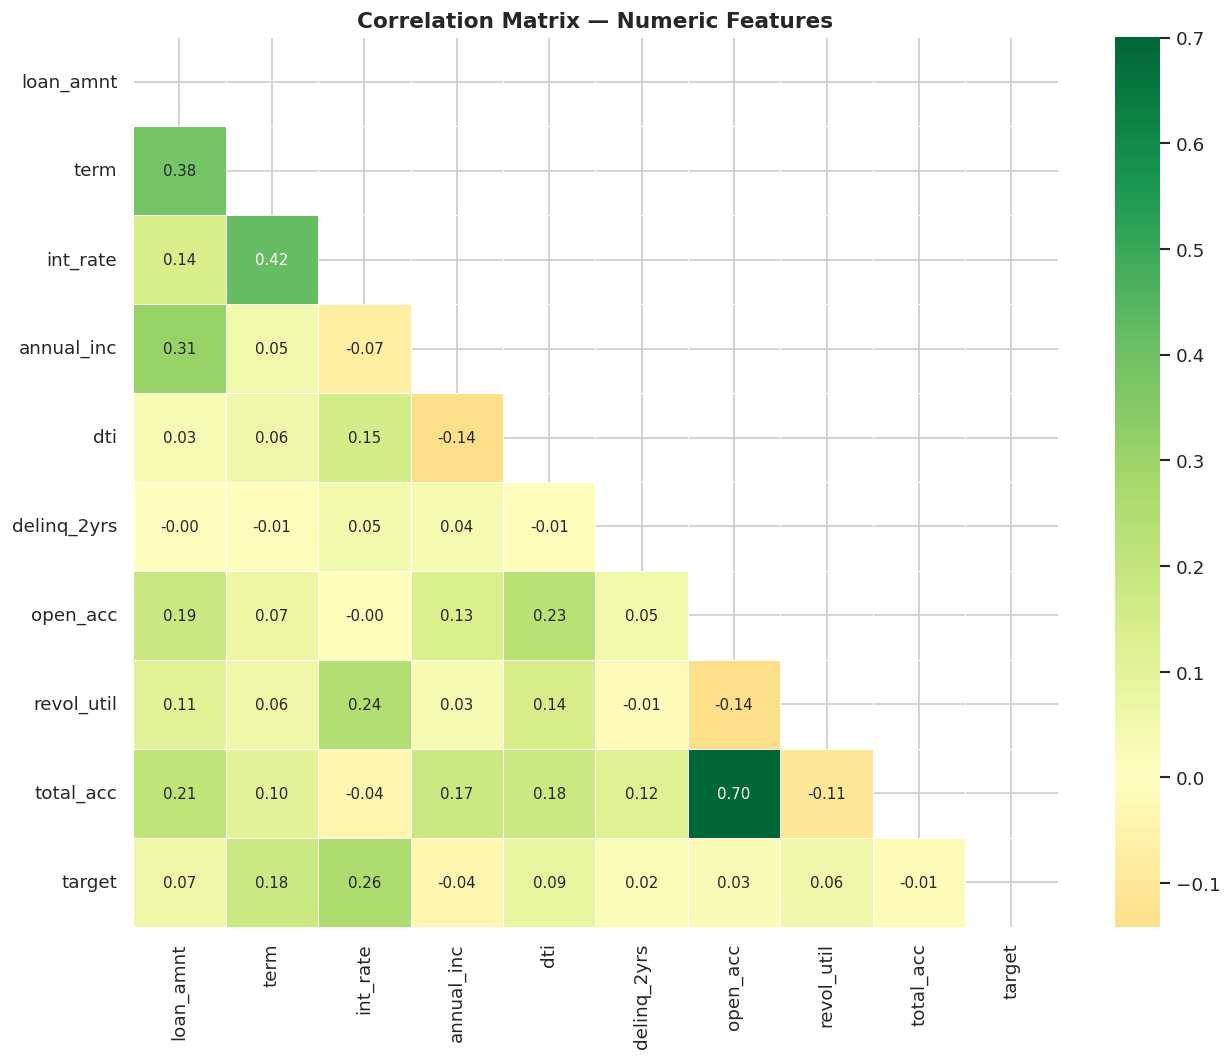

In [ ]:
corr2 = df2[num2+['target']].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr2, mask=np.triu(np.ones_like(corr2, dtype=bool)),
            annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size':9})
ax.set_title('Correlation Matrix — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## Categorical Feature Analysis

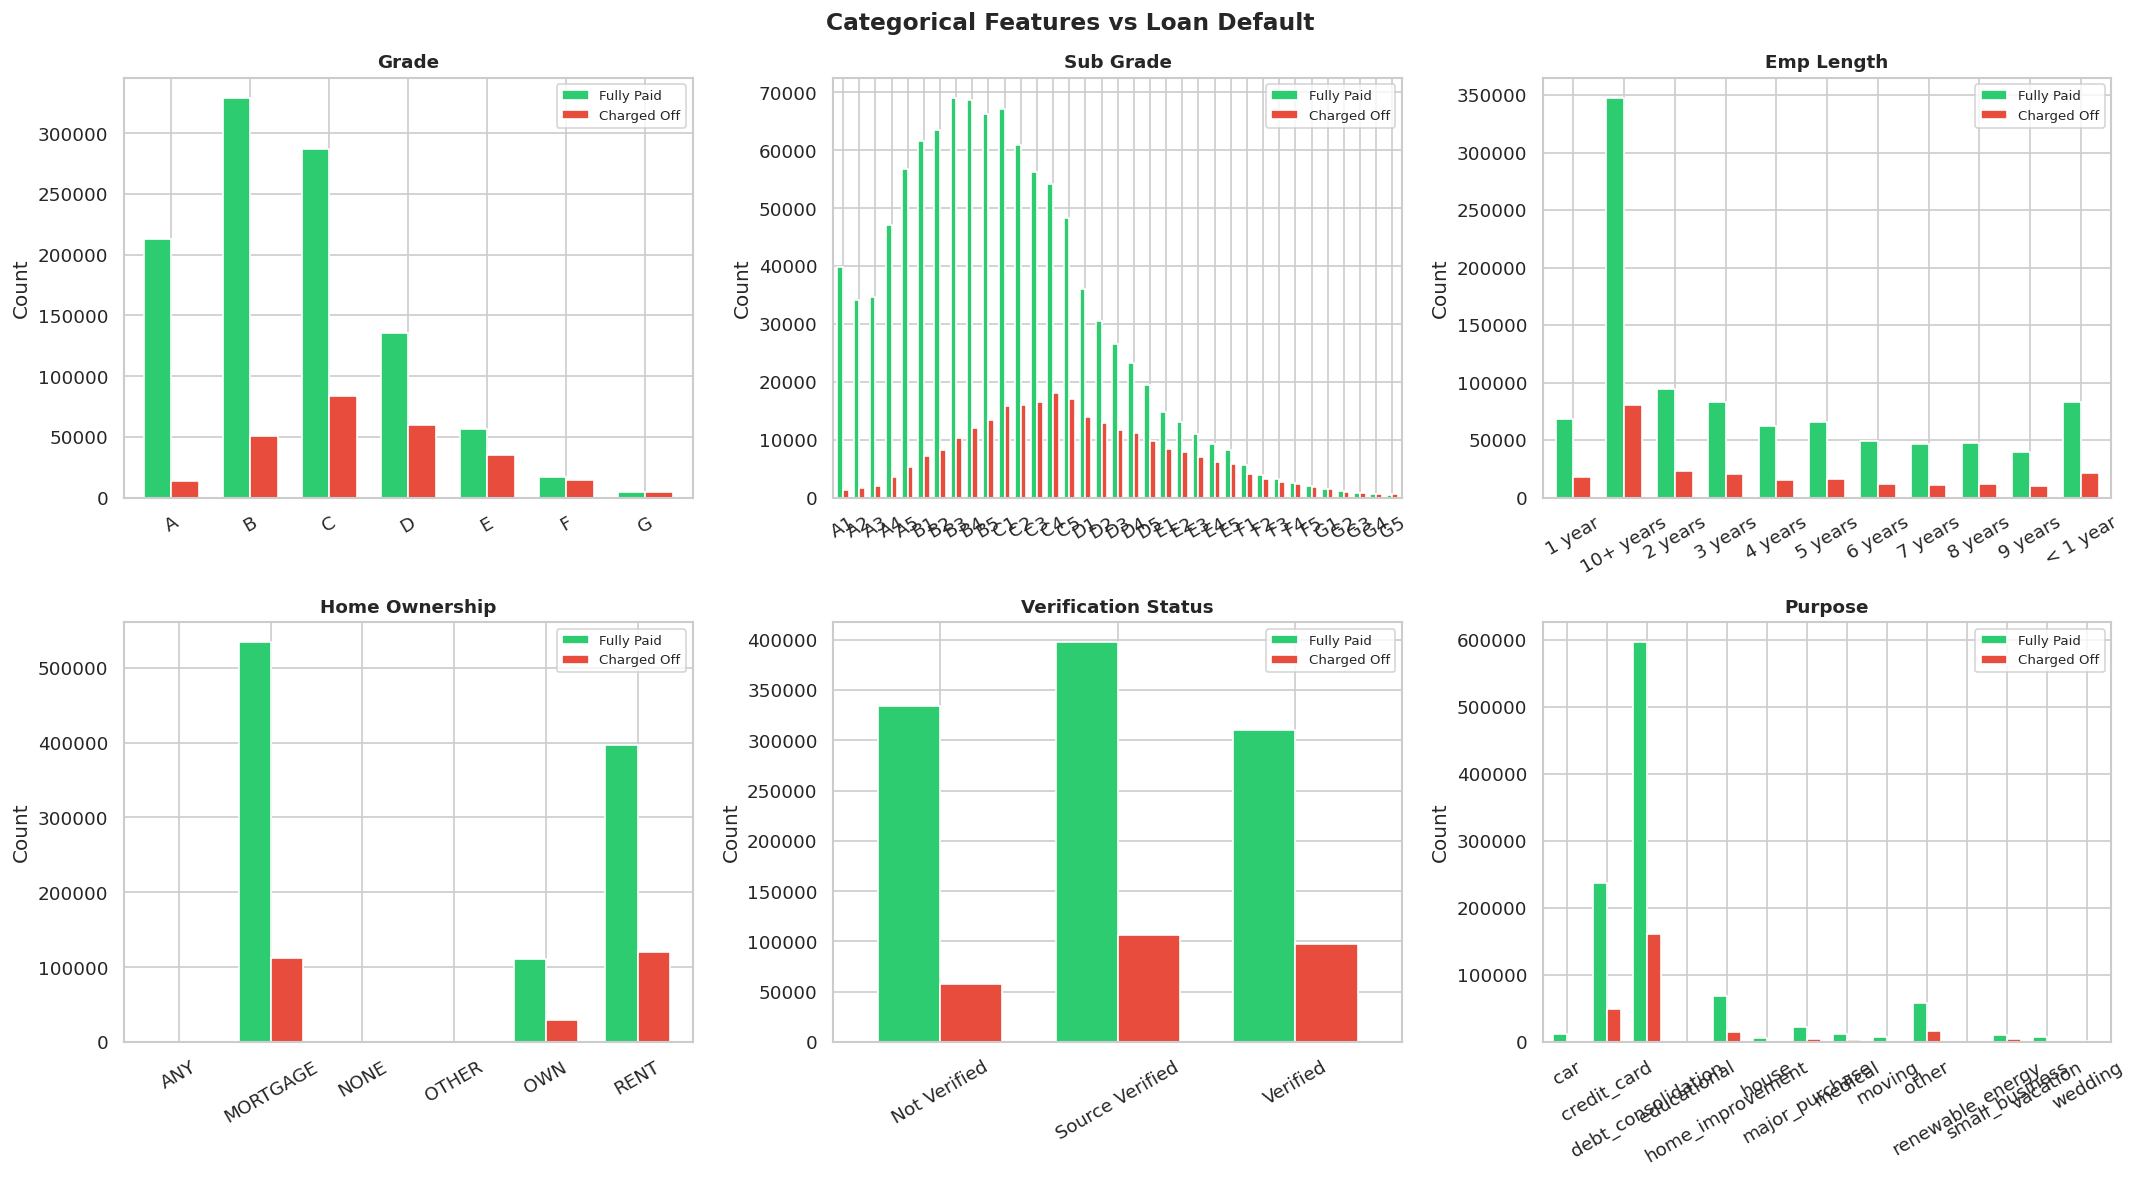

In [ ]:
cat2 = df2.select_dtypes(include='object').columns.tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 10)); axes = axes.flatten()
for i, col in enumerate(cat2[:6]):
    counts = df2.groupby([col,'target']).size().unstack(fill_value=0)
    counts.columns = ['Fully Paid','Charged Off']
    counts.plot(kind='bar', ax=axes[i], color=['#2ecc71','#e74c3c'], edgecolor='white', width=0.7)
    axes[i].set_title(col.replace('_',' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel(''); axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30); axes[i].legend(fontsize=8)
for j in range(len(cat2[:6]), len(axes)): axes[j].set_visible(False)
plt.suptitle('Categorical Features vs Loan Default', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Outlier Detection

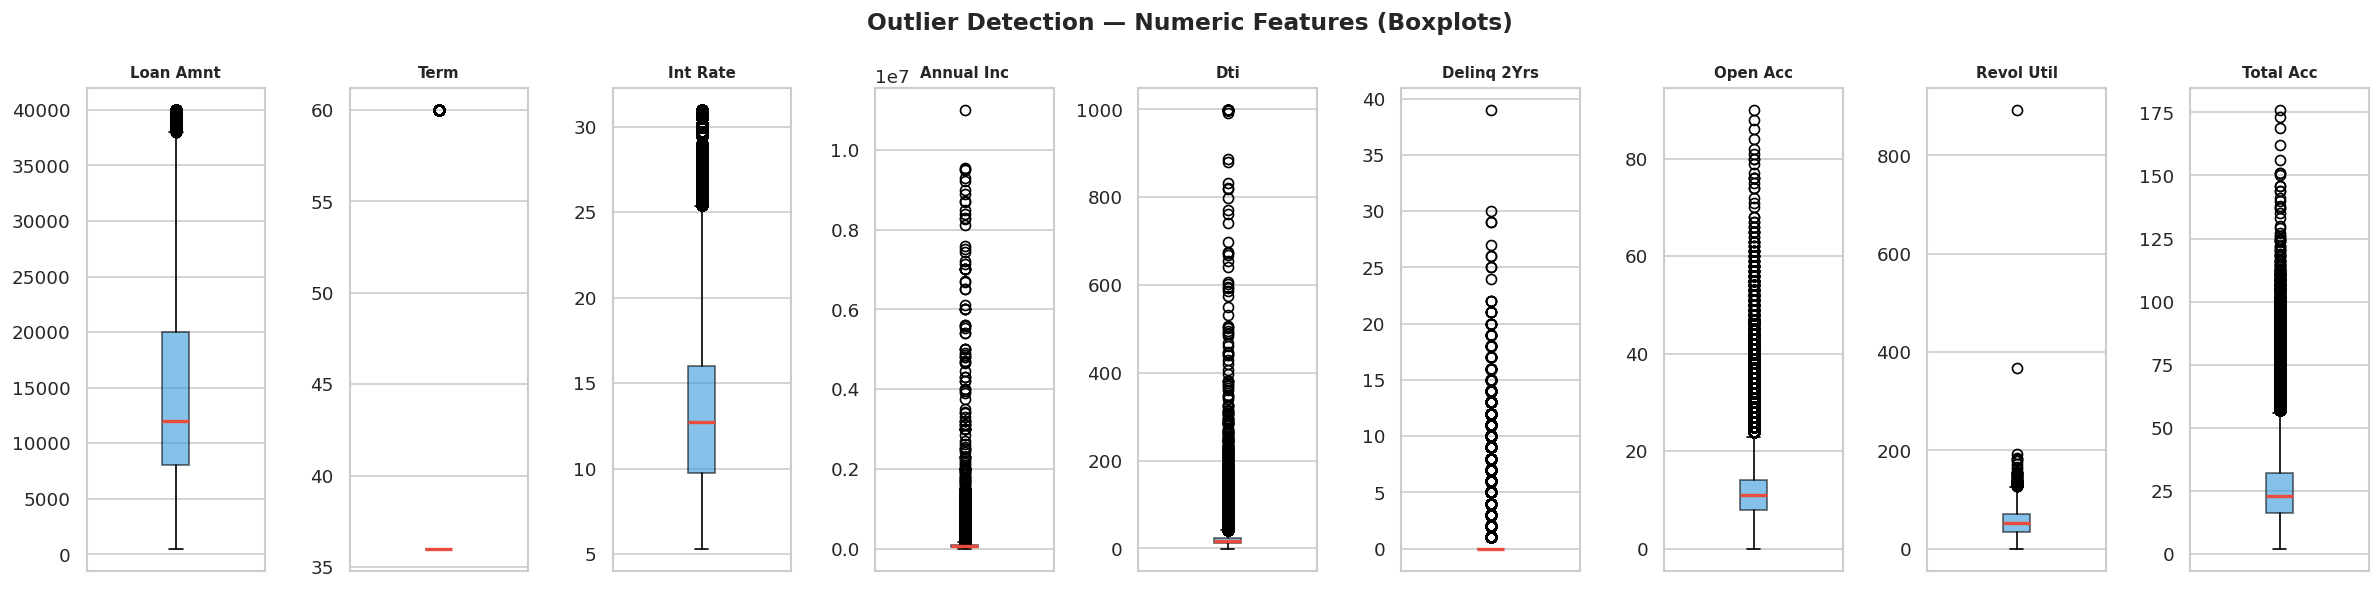

In [ ]:
fig, axes = plt.subplots(1, len(num2), figsize=(20, 5))
for i, col in enumerate(num2):
    axes[i].boxplot(df2[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.6),
                    medianprops=dict(color='#e74c3c', linewidth=2))
    axes[i].set_title(col.replace('_',' ').title(), fontsize=9, fontweight='bold')
    axes[i].set_xticks([])
plt.suptitle('Outlier Detection — Numeric Features (Boxplots)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Loan Amount vs Interest Rate Scatter

/tmp/ipykernel_5382/1690331567.py:10: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  ax.legend(); plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


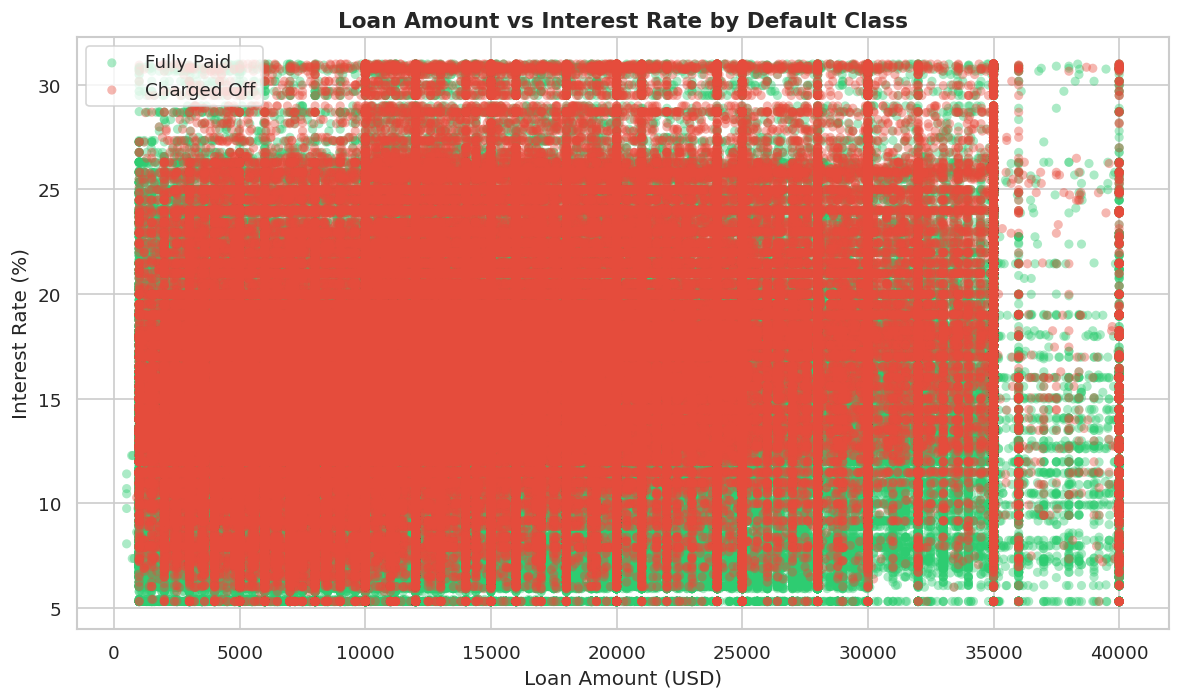

In [ ]:
if 'loan_amnt' in df2.columns and 'int_rate' in df2.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    for t, color, label in [(0,'#2ecc71','Fully Paid'),(1,'#e74c3c','Charged Off')]:
        s = df2[df2['target']==t]
        ax.scatter(s['loan_amnt'], s['int_rate'], alpha=0.4,
                   c=color, label=label, edgecolors='none', s=30)
    ax.set_xlabel('Loan Amount (USD)', fontsize=12)
    ax.set_ylabel('Interest Rate (%)', fontsize=12)
    ax.set_title('Loan Amount vs Interest Rate by Default Class', fontsize=13, fontweight='bold')
    ax.legend(); plt.tight_layout(); plt.show()

## Summary Insights

In [ ]:
p2 = df2[df2['target']==0]; d2 = df2[df2['target']==1]
print('='*58)
print('       EDA SUMMARY — LENDINGCLUB DATASET')
print('='*58)
print(f'  Total samples         : {len(df2)}')
print(f'  Features              : {df2.shape[1]-1}')
print(f'  Fully Paid   (0)      : {len(p2)} ({len(p2)/len(df2)*100:.1f}%)')
print(f'  Charged Off  (1)      : {len(d2)} ({len(d2)/len(df2)*100:.1f}%)')
print(f'  Missing Values        : {df2.isnull().sum().sum()}')
print('-'*58)
if 'loan_amnt' in df2.columns:
    print(f'  Avg Loan Amount       : ${df2["loan_amnt"].mean():,.0f}')
    print(f'    Fully Paid          : ${p2["loan_amnt"].mean():,.0f}')
    print(f'    Charged Off         : ${d2["loan_amnt"].mean():,.0f}')
if 'int_rate' in df2.columns:
    print(f'  Avg Interest Rate     : {df2["int_rate"].mean():.2f}%')
    print(f'    Fully Paid          : {p2["int_rate"].mean():.2f}%')
    print(f'    Charged Off         : {d2["int_rate"].mean():.2f}%')
if 'annual_inc' in df2.columns:
    print(f'  Avg Annual Income     : ${df2["annual_inc"].mean():,.0f}')
if 'dti' in df2.columns:
    print(f'  Avg DTI               : {df2["dti"].mean():.2f}')
print('='*58)

       EDA SUMMARY — LENDINGCLUB DATASET
  Total samples         : 1303607
  Features              : 15
  Fully Paid   (0)      : 1041952 (79.9%)
  Charged Off  (1)      : 261655 (20.1%)
  Missing Values        : 76576
----------------------------------------------------------
  Avg Loan Amount       : $14,417
    Fully Paid          : $14,132
    Charged Off         : $15,549
  Avg Interest Rate     : 13.26%
    Fully Paid          : 12.64%
    Charged Off         : 15.71%
  Avg Annual Income     : $76,159
  Avg DTI               : 18.26


---
# Dataset 3 — Credit Card Fraud Detection

## Load Dataset

In [ ]:
load_fraud_success = False

if os.path.exists(PATHS['fraud']):
    try:
        df3 = pd.read_csv(PATHS['fraud'])
        if 'Class' not in df3.columns:
            raise ValueError("'Class' column not found in creditcard.csv.")
        print(f"Loaded from Drive: {df3.shape[0]} rows x {df3.shape[1]} columns")
        print(f"Fraud cases : {(df3['Class']==1).sum()} ({(df3['Class']==1).mean()*100:.3f}%)")
        load_fraud_success = True
    except (pd.errors.EmptyDataError, ValueError, KeyError) as e:
        print(f"Error loading creditcard.csv: {e}")

if not load_fraud_success:
    raise FileNotFoundError(
        "creditcard.csv not found or could not be loaded.\n"
        "Upload to: MyDrive/CreditRisk_EDA/creditcard.csv\n"
        "Download from: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
    )

Loaded from Drive: 284807 rows x 31 columns
Fraud cases : 492 (0.173%)


## Basic Overview

In [ ]:
print('--- Shape ---'); print(df3.shape)
print('\n--- First 5 Rows ---'); display(df3.head())
print('\n--- Data Types ---'); display(df3.dtypes.to_frame('dtype'))
print('\n--- Statistical Summary ---'); display(df3.describe())

--- Shape ---
(284807, 31)

--- First 5 Rows ---


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



--- Data Types ---


,dtype
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64



--- Statistical Summary ---


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,1.673327e-15,-1.247012e-15,8.190001e-16,1.207294e-15,4.887456e-15,1.437716e-15,-3.772171e-16,9.564149e-16,1.039917e-15,6.406204e-16,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## Missing Values

In [ ]:
missing = df3.isnull().sum()
mdf3 = pd.DataFrame({'Missing Count': missing, 'Missing %': (missing/len(df3)*100).round(2)})
mdf3 = mdf3[mdf3['Missing Count'] > 0]
if mdf3.empty:
    print("No missing values found.")
else:
    display(mdf3)

No missing values found.


## Target Variable Distribution

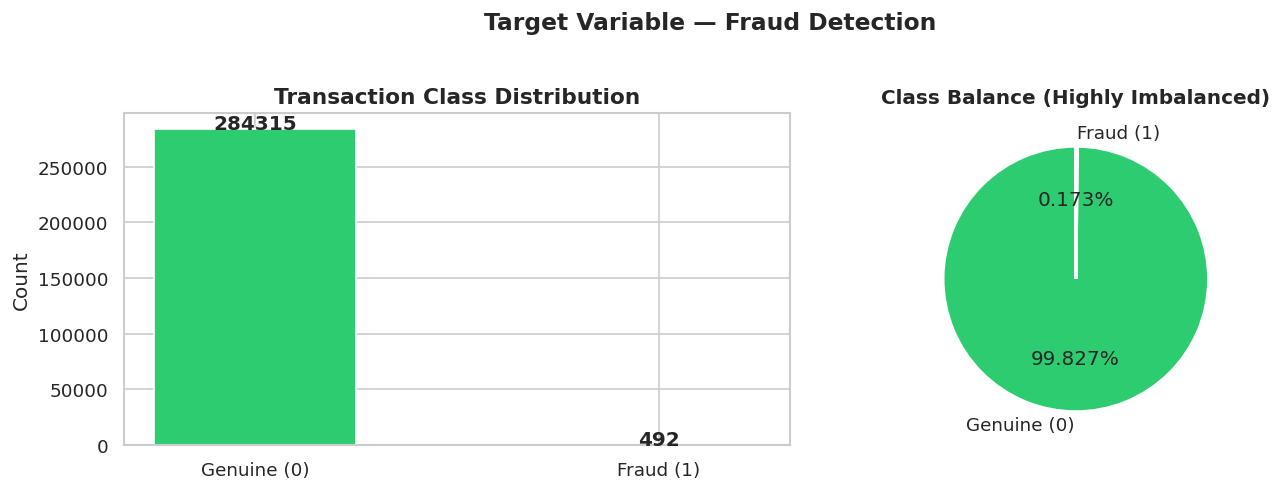

Class
0    284315
1       492

Imbalance ratio: 578:1


In [ ]:
tc3 = df3['Class'].value_counts().sort_index()
tl3 = ['Genuine (0)', 'Fraud (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(tl3, tc3.values, color=['#2ecc71','#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_title('Transaction Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(tc3.values):
    axes[0].text(i, v+10, str(v), ha='center', fontweight='bold')
axes[1].pie(tc3.values, labels=tl3, autopct='%1.3f%%',
            colors=['#2ecc71','#e74c3c'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Class Balance (Highly Imbalanced)', fontsize=12, fontweight='bold')
plt.suptitle('Target Variable — Fraud Detection', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
print(tc3.to_string())
print(f'\nImbalance ratio: {tc3[0]/tc3[1]:.0f}:1')

## Feature Distributions (Amount, Time & V1–V6)

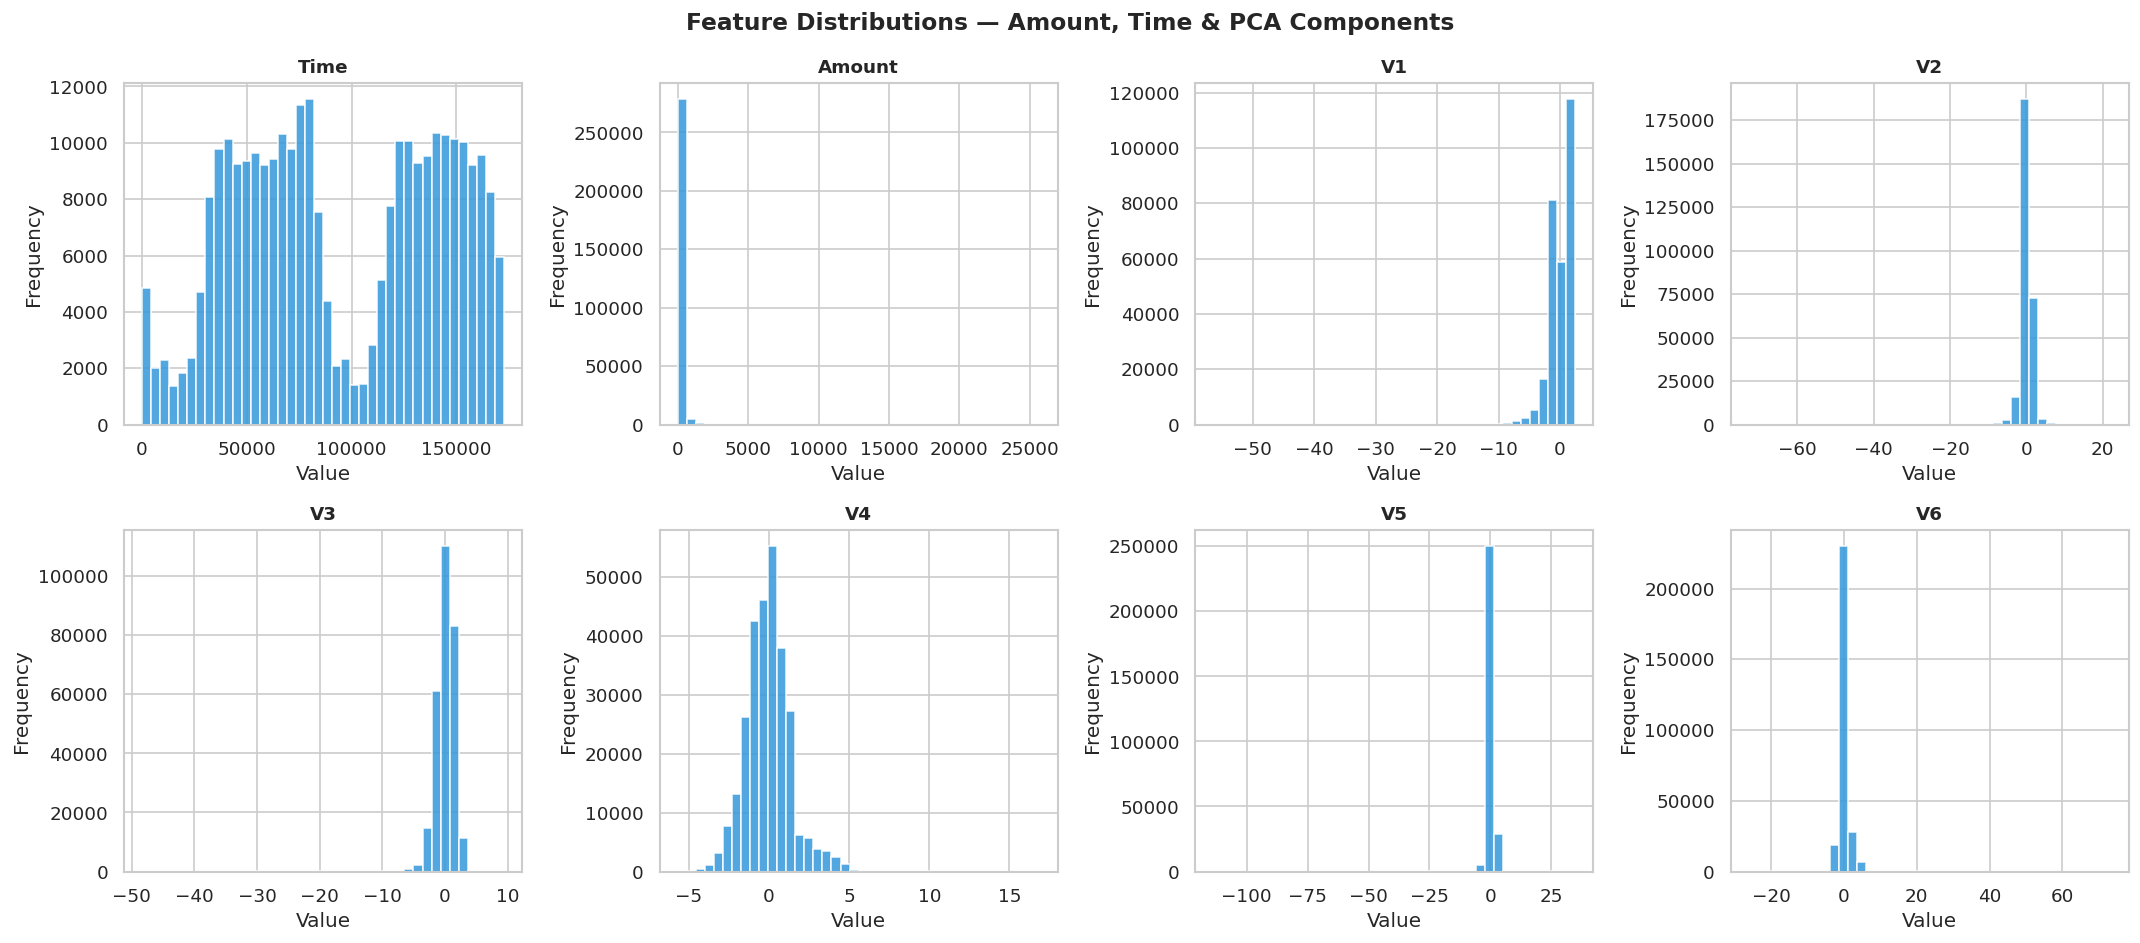

In [ ]:
disp3 = [c for c in ['Time','Amount','V1','V2','V3','V4','V5','V6'] if c in df3.columns]
ncols = 4; nrows = (len(disp3)+ncols-1)//ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4*nrows)); axes = axes.flatten()
for i, col in enumerate(disp3):
    axes[i].hist(df3[col], bins=40, color='#3498db', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value'); axes[i].set_ylabel('Frequency')
for j in range(len(disp3), len(axes)): axes[j].set_visible(False)
plt.suptitle('Feature Distributions — Amount, Time & PCA Components', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Key Features vs Fraud Class

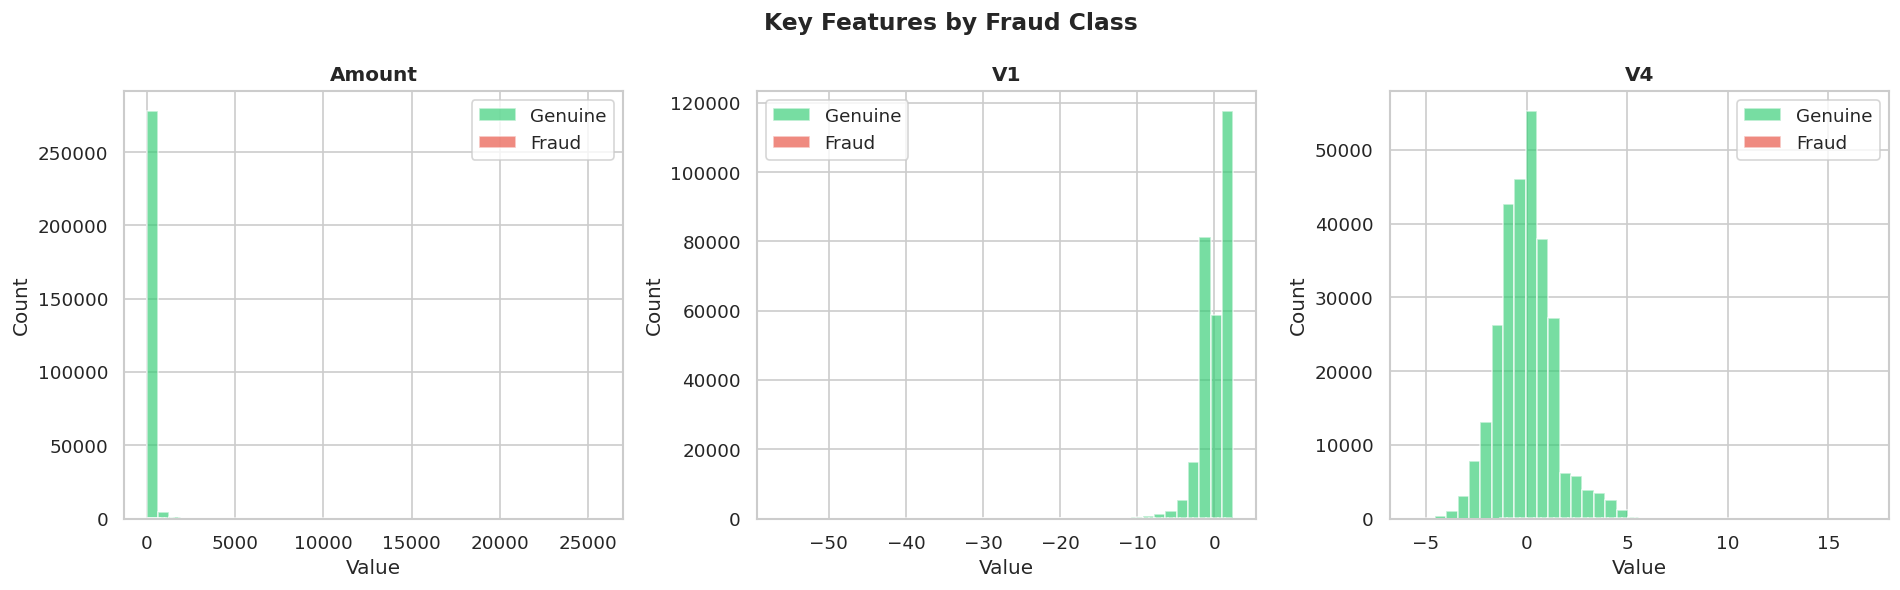

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
c_ = {0:'#2ecc71', 1:'#e74c3c'}; l_ = {0:'Genuine', 1:'Fraud'}
key3 = [c for c in ['Amount','V1','V4'] if c in df3.columns]
for i, col in enumerate(key3):
    for t in [0, 1]:
        axes[i].hist(df3[df3['Class']==t][col], bins=40, alpha=0.65,
                     color=c_[t], label=l_[t], edgecolor='white')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value'); axes[i].set_ylabel('Count'); axes[i].legend()
plt.suptitle('Key Features by Fraud Class', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Correlation Heatmap (Amount, Time & V1–V10)

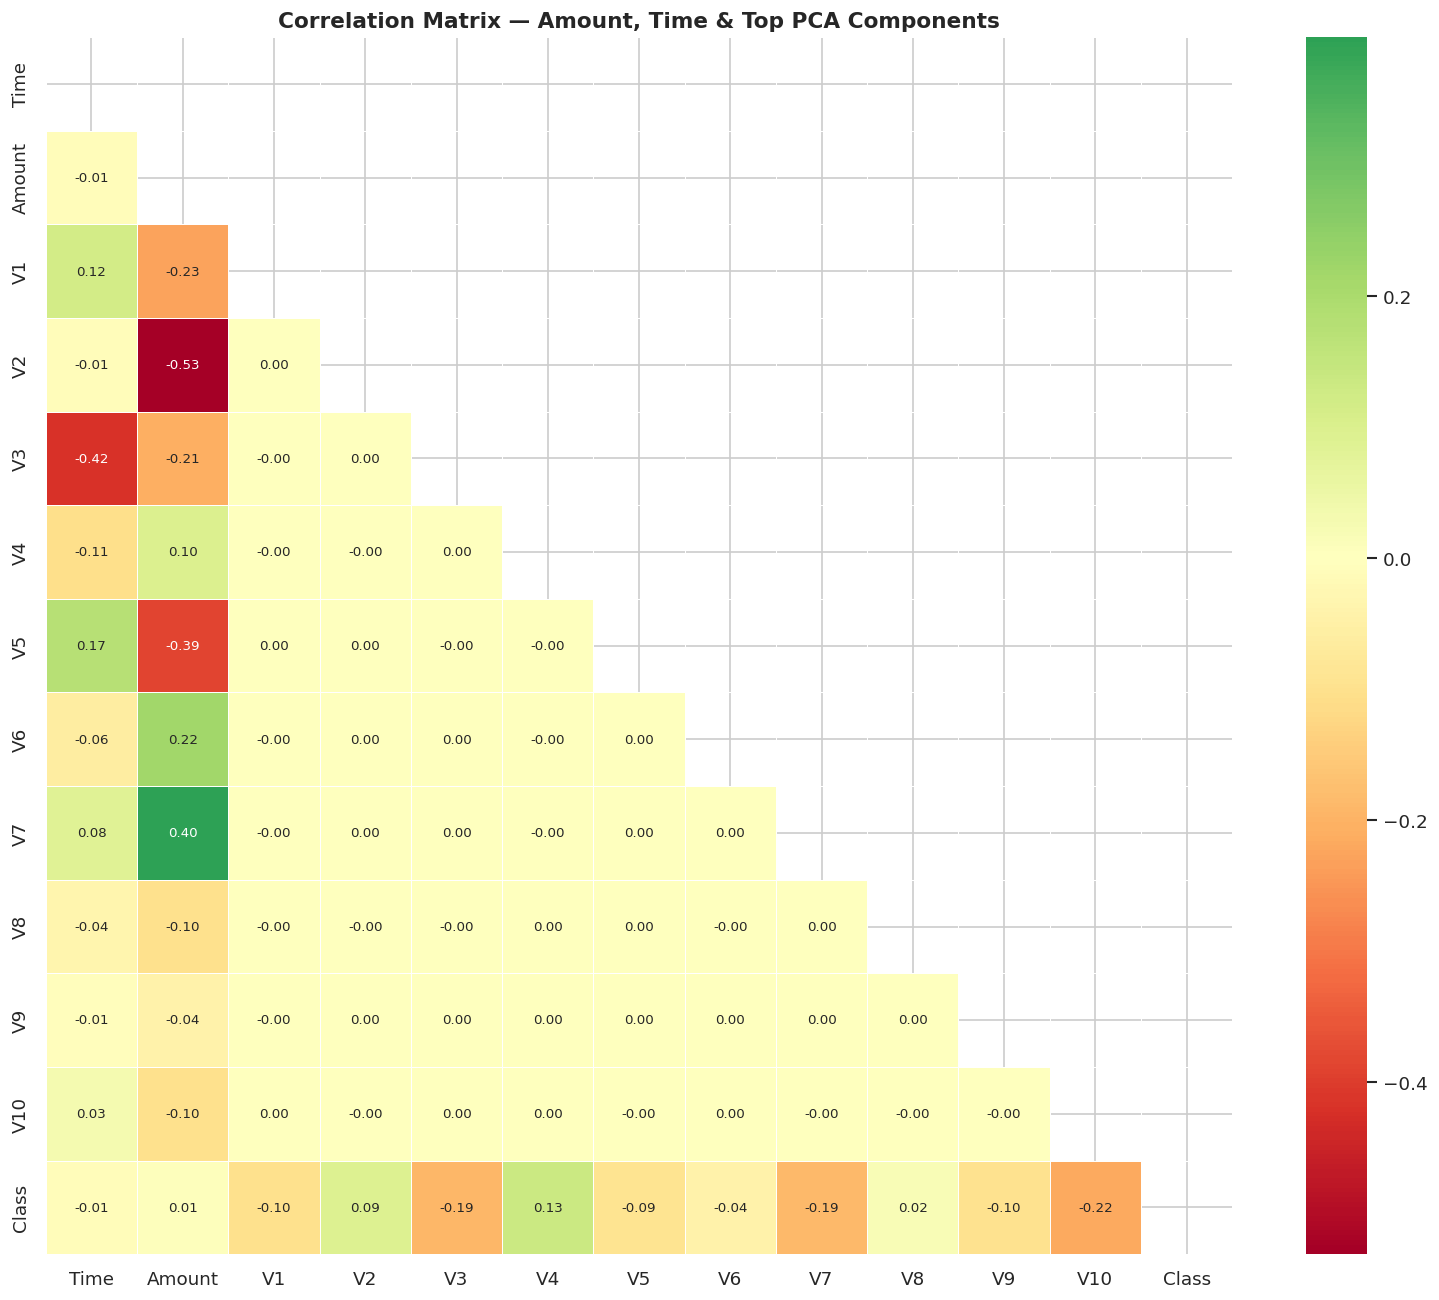

In [ ]:
cc3 = [c for c in ['Time','Amount']+[f'V{i}' for i in range(1,11)]+['Class'] if c in df3.columns]
corr3 = df3[cc3].corr()
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr3, mask=np.triu(np.ones_like(corr3, dtype=bool)),
            annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size':8})
ax.set_title('Correlation Matrix — Amount, Time & Top PCA Components', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## PCA Components V1–V12 by Fraud Class

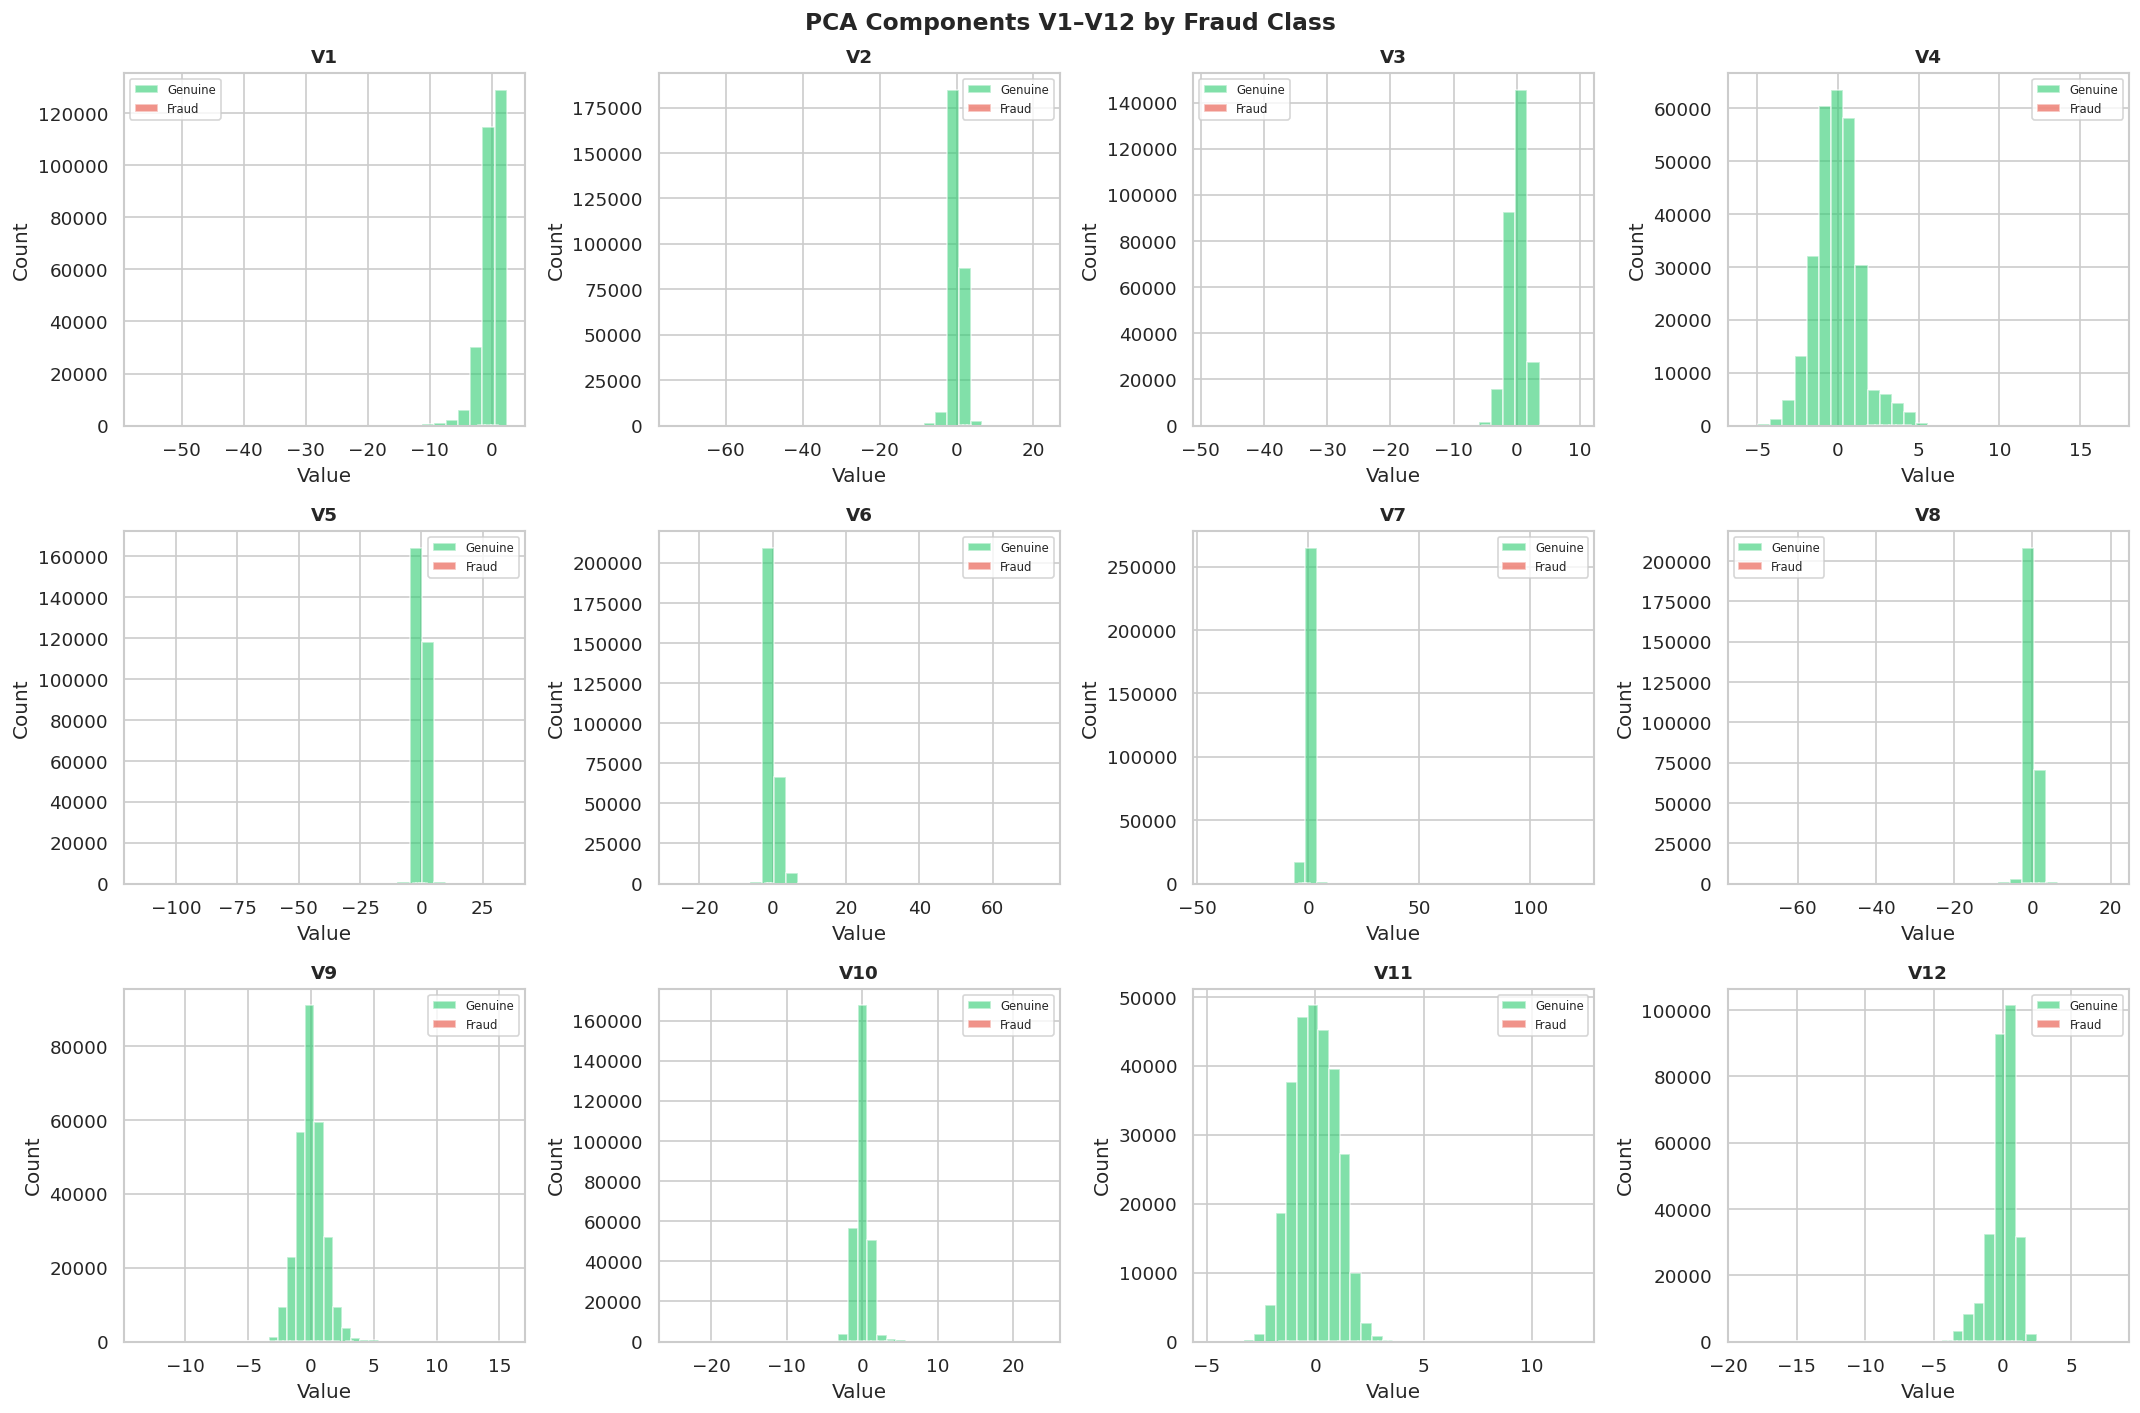

In [ ]:
pca3 = [f'V{i}' for i in range(1,13) if f'V{i}' in df3.columns]
fig, axes = plt.subplots(3, 4, figsize=(18, 12)); axes = axes.flatten()
c_ = {0:'#2ecc71', 1:'#e74c3c'}; l_ = {0:'Genuine', 1:'Fraud'}
for i, col in enumerate(pca3):
    for t in [0, 1]:
        axes[i].hist(df3[df3['Class']==t][col], bins=30, alpha=0.60,
                     color=c_[t], label=l_[t], edgecolor='white')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value'); axes[i].set_ylabel('Count'); axes[i].legend(fontsize=7)
plt.suptitle('PCA Components V1–V12 by Fraud Class', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Outlier Detection

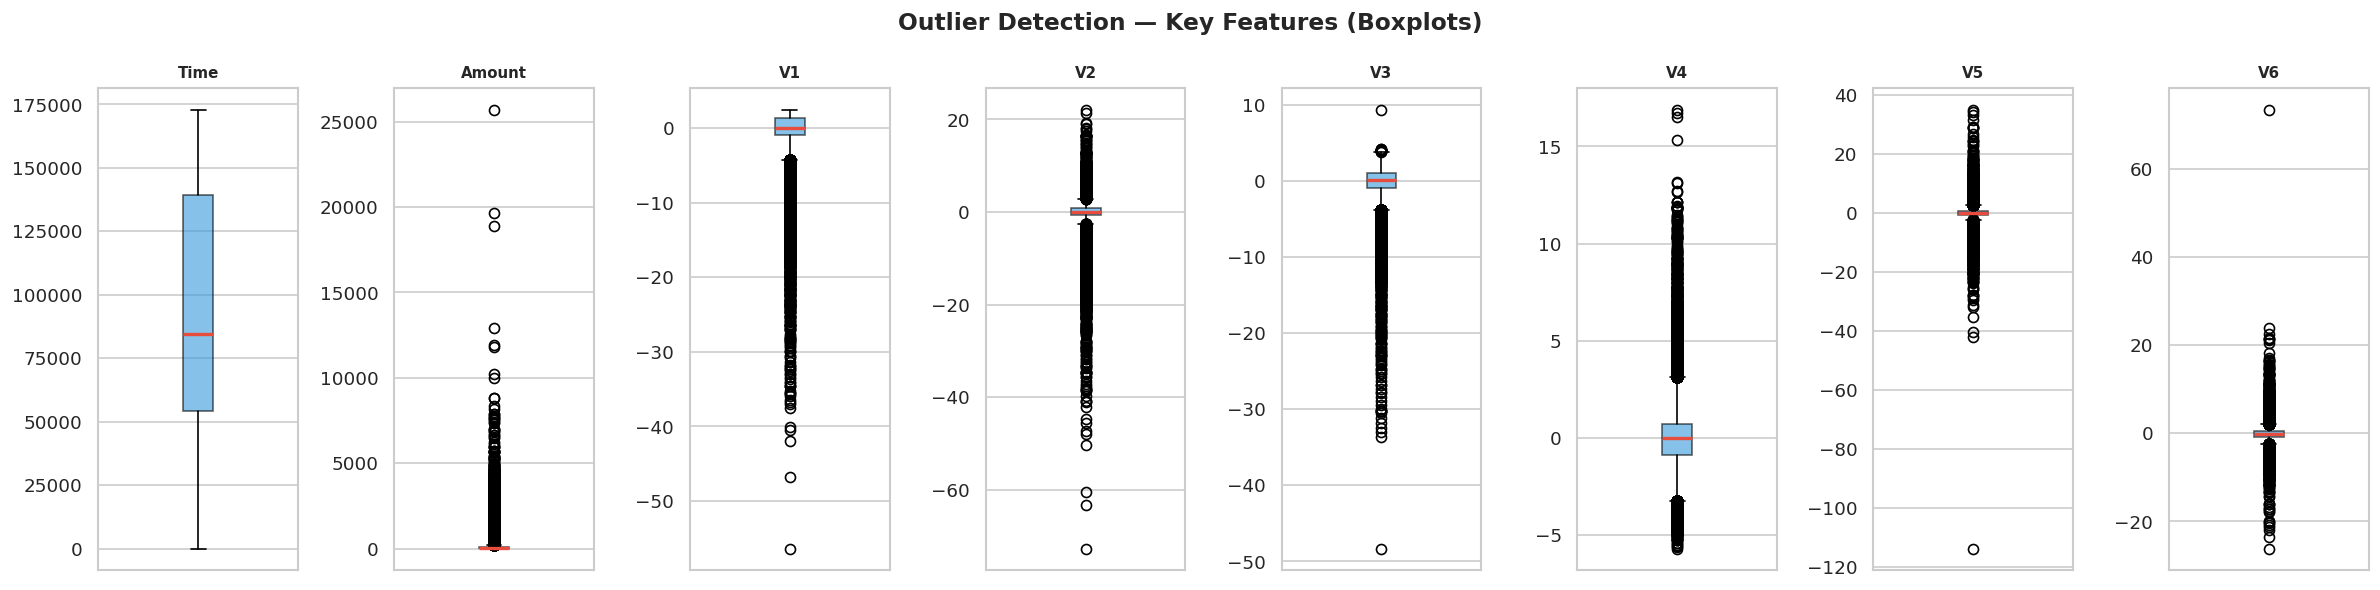

In [ ]:
chk3 = [c for c in ['Time','Amount','V1','V2','V3','V4','V5','V6'] if c in df3.columns]
fig, axes = plt.subplots(1, len(chk3), figsize=(20, 5))
for i, col in enumerate(chk3):
    axes[i].boxplot(df3[col], patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.6),
                    medianprops=dict(color='#e74c3c', linewidth=2))
    axes[i].set_title(col, fontsize=9, fontweight='bold'); axes[i].set_xticks([])
plt.suptitle('Outlier Detection — Key Features (Boxplots)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Transaction Amount vs Time Scatter

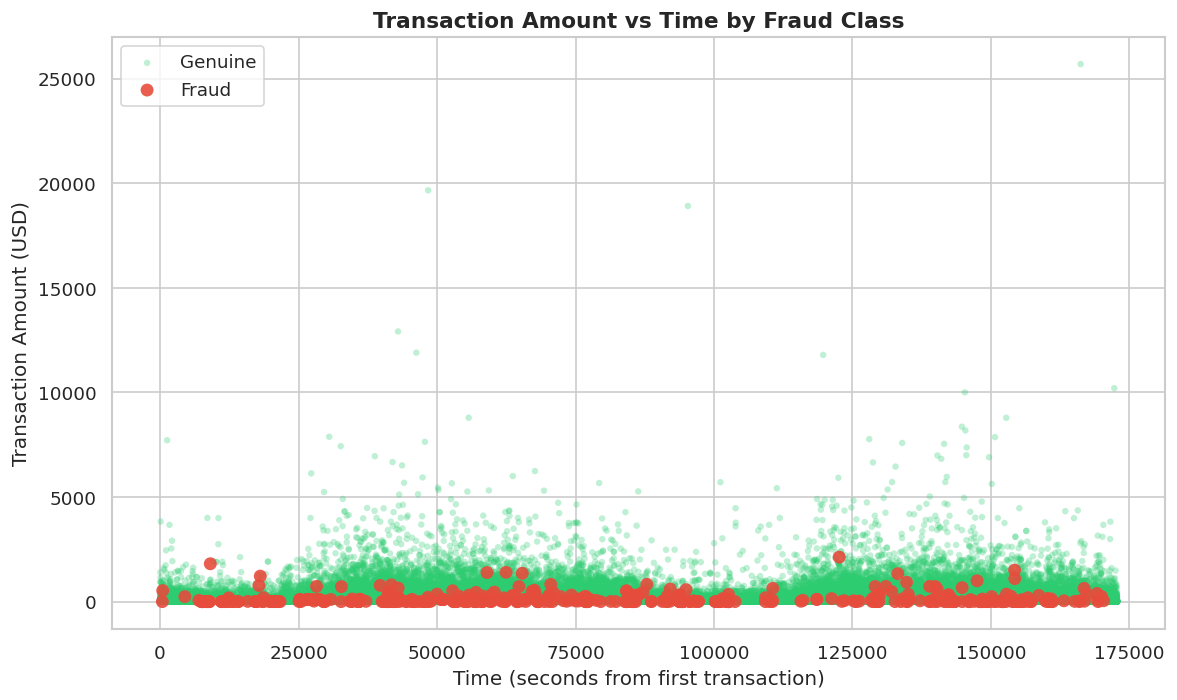

In [ ]:
if 'Time' in df3.columns and 'Amount' in df3.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    for t, color, label, sz in [(0,'#2ecc71','Genuine',15),(1,'#e74c3c','Fraud',60)]:
        s = df3[df3['Class']==t]
        ax.scatter(s['Time'], s['Amount'], alpha=0.3 if t==0 else 0.9,
                   c=color, label=label, edgecolors='none', s=sz)
    ax.set_xlabel('Time (seconds from first transaction)', fontsize=12)
    ax.set_ylabel('Transaction Amount (USD)', fontsize=12)
    ax.set_title('Transaction Amount vs Time by Fraud Class', fontsize=13, fontweight='bold')
    ax.legend(); plt.tight_layout(); plt.show()

## Summary Insights

In [ ]:
gen3 = df3[df3['Class']==0]; fr3 = df3[df3['Class']==1]
print('='*60)
print('   EDA SUMMARY — CREDIT CARD FRAUD DETECTION')
print('='*60)
print(f'  Total transactions     : {len(df3)}')
print(f'  Features               : {df3.shape[1]-1}  (V1-V28, Time, Amount)')
print(f'  Genuine (0)            : {len(gen3)} ({len(gen3)/len(df3)*100:.3f}%)')
print(f'  Fraud   (1)            : {len(fr3)}  ({len(fr3)/len(df3)*100:.3f}%)')
print(f'  Missing Values         : {df3.isnull().sum().sum()}')
print('-'*60)
print(f'  Avg Transaction Amount : ${df3["Amount"].mean():.2f}')
print(f'    Genuine              : ${gen3["Amount"].mean():.2f}')
print(f'    Fraud                : ${fr3["Amount"].mean():.2f}')
print(f'  Max Transaction Amount : ${df3["Amount"].max():.2f}')
if 'Time' in df3.columns:
    print(f'  Time span              : {df3["Time"].max()/3600:.1f} hours')
print('='*60)

   EDA SUMMARY — CREDIT CARD FRAUD DETECTION
  Total transactions     : 284807
  Features               : 30  (V1-V28, Time, Amount)
  Genuine (0)            : 284315 (99.827%)
  Fraud   (1)            : 492  (0.173%)
  Missing Values         : 0
------------------------------------------------------------
  Avg Transaction Amount : $88.35
    Genuine              : $88.29
    Fraud                : $122.21
  Max Transaction Amount : $25691.16
  Time span              : 48.0 hours
